## Libraries

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os
import gc
import scipy.stats as stats
from collections import defaultdict
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import spearmanr, pearsonr
from IPython.display import display, Markdown
from sklearn.model_selection import GroupKFold
import lightgbm as lgb
import optuna
from catboost import CatBoostRegressor, Pool

# configuration
warnings.simplefilter('ignore')
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

## Functions

In [2]:
def load_data():
    print("Loading training data...")
    train_df = pd.read_parquet(DATA_PATH + "train.parquet")
    print("Loading test data...")
    test_df = pd.read_parquet(DATA_PATH + "test.parquet")
    print("Memory optimization...")
    train_df = reduce_mem_usage(train_df)
    test_df  = reduce_mem_usage(test_df)
    print("Done!")
    return train_df, test_df

def reduce_mem_usage(df):
    """ iterate through all the columns of a dataframe and modify the data type
        to reduce memory usage.        
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
    
    return df

def weighted_rmse_ratio(y_true: np.ndarray, y_pred: np.ndarray, w: np.ndarray) -> float:
    """
    Compute Weighted RMSE Ratio:
      ratio = sum(w*(y-yhat)^2) / sum(w*y^2)
    """
    denom = np.sum(w * (y_true ** 2))
    if denom <= 0:
        return 1.0
    return float(np.sum(w * ((y_true - y_pred) ** 2)) / denom)


def competition_score(y_true: np.ndarray, y_pred: np.ndarray, w: np.ndarray) -> float:
    """
      score = sqrt( 1 - clip01(ratio) )
    where ratio = sum(w*(y-yhat)^2) / sum(w*y^2).
    """
    ratio = weighted_rmse_ratio(y_true, y_pred, w)
    ratio = float(np.minimum(np.maximum(ratio, 0.0), 1.0))
    return float(np.sqrt(1.0 - ratio))


def lgb_custom_metric(y_pred: np.ndarray, dataset: lgb.Dataset):
    """
    LightGBM custom metric computation: returns (name, value, is_higher_better)
    """
    y_true = dataset.get_label()
    w = dataset.get_weight()
    if w is None:
        w = np.ones_like(y_true, dtype=np.float32)
    score = competition_score(y_true, y_pred, w)
    return "competition_score", score, True


def make_time_split(df: pd.DataFrame, valid_fraction: float = 0.2):
    """
    Leakage-free split on time: train on early ts_index, validate on later ts_index.
    """
    ts_values = np.sort(df["ts_index"].unique())
    cut = ts_values[int((1.0 - valid_fraction) * len(ts_values))]
    trn_idx = df.index[df["ts_index"] <= cut]
    val_idx = df.index[df["ts_index"] > cut]
    return trn_idx, val_idx, cut


In [3]:
def describe_dataset(df: pd.DataFrame):
    """
    Overview of a DataFrame, including
    dimensions, memory usage, data types, and detailed descriptive statistics.

    Args:
        df (pd.DataFrame): The input DataFrame to describe.
    """
    
    display(Markdown("## 📋 Dataset Overview"))
    print("--- Basic Dimensions & Memory ---")
    
    # shape
    num_rows, num_cols = df.shape
    print(f"**Shape (Rows, Columns):** ({num_rows:,}, {num_cols:,})")
    
    # memory
    mem_usage = df.memory_usage(deep=True).sum()
    mem_gbs = mem_usage / (1024**2)
    print(f"**Total Memory Usage:** {mem_gbs:.2f} MB")
    
    print("\n--- Feature Data Types and Counts ---")
    
    # data types
    dtype_counts = df.dtypes.astype(str).value_counts().reset_index()
    dtype_counts.columns = ['Data_Type', 'Count']
    print(dtype_counts.to_markdown(index=False))

    
    # stats
    display(Markdown("\n## 📊 Descriptive Statistics"))
    
    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    datetime_cols = df.select_dtypes(include=['datetime']).columns.tolist()

    # numerical
    if numerical_cols:
        display(Markdown("### Numerical Features"))
        # Use transpose for better readability when many features exist
        num_desc = df[numerical_cols].describe().T
        # Add IQR for a more detailed statistical view
        num_desc['IQR'] = num_desc['75%'] - num_desc['25%']
        display(num_desc.style.format("{:,.2f}"))
        print(f"Found {len(numerical_cols)} numerical features.")

    # categorical
    if categorical_cols:
        display(Markdown("### Categorical / Object Features"))
        # Include top, frequency, and unique count
        cat_desc = df[categorical_cols].describe().T
        display(cat_desc.style.format({"unique": "{:,}", "freq": "{:,}"}))
        print(f"Found {len(categorical_cols)} categorical/object features.")

    # datetime
    if datetime_cols:
        display(Markdown("### Datetime Features"))
        dt_desc = df[datetime_cols].describe().T
        display(dt_desc)
        print(f"Found {len(datetime_cols)} datetime features.")


def missing_duplicates_analysis(df: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    print("--- 📊 Missing Data and Duplicates Analysis ---")
    # missing summary
    missing_counts = df.isnull().sum()
    missing_summary = pd.DataFrame({
        'Missing_Count': missing_counts,
        'Missing_Percent': 100 * missing_counts / len(df)
    })
    missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]
    missing_summary = missing_summary.sort_values(by='Missing_Count', ascending=False)
    
    
    # check for duplicates
    num_duplicates = df.duplicated().sum()
    print(f"**Duplicate rows found:** {df.duplicated().sum()}")
    
    # visualisation
    if missing_summary.empty:
        print("✅ **No missing values found** in the dataset.")
        return pd.DataFrame()
    
    print(f"\n**Total features with missing values:** {len(missing_summary)}")
    
    # Select the top n features
    plot_data = missing_summary.head(top_n)
    
    plt.style.use('ggplot')
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=plot_data.index,
        y='Missing_Count',
        data=plot_data,
        palette='viridis'
    )
    
    # Add percentage labels above the bars
    for i, count in enumerate(plot_data['Missing_Count']):
        percent = plot_data['Missing_Percent'].iloc[i]
        plt.text(
            x=i, 
            y=count + (df.shape[0] * 0.005),
            s=f'{percent:.1f}%',
            ha='center',
            fontsize=9
        )
    
    plt.title(f"Top {min(top_n, len(missing_summary))} Features by Missing Values Count (Total Rows: {len(df)})", 
              fontsize=14, fontweight='bold')
    plt.xlabel("Feature Name", fontsize=12)
    plt.ylabel("Missing Count", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    print("\n**Missing Data Summary Table (Top 10):**")
    print(missing_summary.head(10).to_markdown(floatfmt=".2f"))
    return missing_summary

def plot_missing_over_time(df, feature):
    tmp = df.copy()
    tmp["is_missing"] = tmp[feature].isna().astype(int)

    missing_rate = (
        tmp.groupby("ts_index")["is_missing"]
           .mean()
    )

    plt.figure(figsize=(10,4))
    plt.plot(missing_rate)
    plt.title(f"Missing rate over time: {feature}")
    plt.ylabel("Missing %")
    plt.xlabel("ts_index")
    plt.show()

def plot_overall_missing_drift(df, time_col="ts_index"):
    missing_over_time = (
        df.isna()
          .groupby(df[time_col])
          .mean()
          .mean(axis=1)
    )

    plt.figure(figsize=(12,4))
    plt.plot(missing_over_time)
    plt.title("Overall Missing % Across All Features Over Time")
    plt.ylabel("Average Missing Rate")
    plt.xlabel("ts_index")
    plt.show()

def detect_outliers(df, method='iqr', threshold=2.5, z_threshold=3.0, cols=None, summary=True):

    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if method not in ['iqr', 'zscore']:
        raise ValueError("method must be 'iqr' or 'zscore'")

    outlier_flags = pd.DataFrame(False, index=df.index, columns=cols)

    for col in cols:
        series = df[col].dropna()

        if method == 'iqr':
            Q1 = series.quantile(0.25)
            Q3 = series.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - threshold * IQR
            upper_bound = Q3 + threshold * IQR
            outlier_flags[col] = (df[col] < lower_bound) | (df[col] > upper_bound)

        elif method == 'zscore':
            z_scores = np.abs(stats.zscore(series))
            outlier_flags[col] = z_scores > z_threshold

    if summary:
        summary_df = pd.DataFrame({
            'outlier_count': outlier_flags.sum(),
            'percent_outliers': 100 * outlier_flags.sum() / len(df)
        }).sort_values('percent_outliers', ascending=False)

        print("📊 Outlier Detection Summary:")
        print(summary_df.round(2))
        return outlier_flags, summary_df

    return outlier_flags


def corr_summary(df, features, target="y_target"):
    rows = []
    for f in features:
        s_corr = spearmanr(df[f], df[target], nan_policy="omit").correlation
        p_corr = pearsonr(df[f].fillna(0), df[target])[0]
        rows.append((f, s_corr, p_corr))
    return (
        pd.DataFrame(rows, columns=["feature", "spearman", "pearson"])
          .sort_values("spearman", key=np.abs, ascending=False)
    )


def plot_target_boxplot_by_range(
    df: pd.DataFrame,
    category_col: str,
    target_col: str = "y_target",
    top_k: int = 10,
    range_method: str = "iqr",  # "iqr" or "minmax"
    figsize=(12, 4),
    showfliers: bool = False
):
    """
    Plot boxplots of target distribution for top-K categories,
    ordered by distribution range.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe (already sampled if large).
    category_col : str
        Categorical column to group by (e.g. 'sub_category').
    target_col : str
        Target variable.
    top_k : int
        Number of top categories to display (by frequency).
    range_method : str
        'iqr' (Q75-Q25) or 'minmax'.
    figsize : tuple
        Figure size.
    showfliers : bool
        Whether to show outliers in boxplot.
    """

    # ------------------------------------------------------------------
    # Select top-K categories by frequency
    # ------------------------------------------------------------------
    top_categories = df[category_col].value_counts().head(top_k).index.tolist()
    tmp = df[df[category_col].isin(top_categories)]
    if pd.api.types.is_categorical_dtype(tmp[category_col]):
        tmp[category_col] = tmp[category_col].cat.remove_unused_categories()
    # ------------------------------------------------------------------
    # Compute distribution range per category
    # ------------------------------------------------------------------
    if range_method == "iqr":
        ranges = (
            tmp.groupby(category_col)[target_col]
               .quantile([0.25, 0.75])
               .unstack()
        )
        ranges["range"] = ranges[0.75] - ranges[0.25]

    elif range_method == "minmax":
        ranges = (
            tmp.groupby(category_col)[target_col]
               .agg(["min", "max"])
        )
        ranges["range"] = ranges["max"] - ranges["min"]

    else:
        raise ValueError("range_method must be 'iqr' or 'minmax'")
    
    # Sort categories by decreasing range
    ordered_categories = (
        ranges.sort_values("range", ascending=False)
              .index
              .tolist()
    )

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    plt.figure(figsize=figsize)
    sns.boxplot(
        data=tmp,
        x=category_col,
        y=target_col,
        order=ordered_categories,
        showfliers=showfliers
    )
    plt.title(
        f"{target_col} distribution by {category_col} "
        f"(top {top_k})"
    )
    plt.xticks(rotation=45)
    plt.show()


def plot_scatter_feature_vs_target(
    df,
    feature,
    target="y_target",
    sample=30000
):
    # ------------------------------------------------
    # Sample & clean
    # ------------------------------------------------
    tmp = (
        df[[feature, target]]
        .dropna()
        .sample(n=min(sample, df[[feature, target]].dropna().shape[0]),
                random_state=42)
    )

    if tmp.shape[0] < 10:
        print(f"[WARN] Not enough data to plot {feature}")
        return

    x = tmp[feature].values
    y = tmp[target].values

    # ------------------------------------------------
    # Correlations
    # ------------------------------------------------
    pearson = pearsonr(x, y)[0]
    spearman = spearmanr(x, y).correlation

    print(f"{feature} vs {target}")
    print(f"  Pearson  r = {pearson:.4f}")
    print(f"  Spearman ρ = {spearman:.4f}")

    # ------------------------------------------------
    # Plot
    # ------------------------------------------------
    plt.figure(figsize=(6, 4))
    sns.regplot(
        x=feature,
        y=target,
        data=tmp,
        lowess=True,
        scatter_kws={"alpha": 0.2, "s": 10},
        line_kws={"color": "red"}
    )

    plt.title(
        f"{feature} vs {target}\n"
        f"Pearson r={pearson:.3f} | Spearman ρ={spearman:.3f}"
    )
    plt.show()


def plot_correlation_matrix(df, numeric_features):
    # Compute correlation matrix
    df = df[numeric_features]
    corr_matrix = df.corr()

    # Create a mask to hide the upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    # Set up the matplotlib figure
    plt.figure(figsize=(16, 10))

    # Plot heatmap with the mask
    sns.heatmap(corr_matrix, mask=mask, annot=True,
                cmap="coolwarm", fmt=".2f", linewidths=0.5)

    # Title
    plt.title("Feature Correlation Heatmap")
    plt.show()


def plot_std_over_time(df, features, title):
    plt.figure(figsize=(12,6))
    for col in features:
        df.groupby("ts_index")[col].std().plot(label=col)
    plt.legend()
    plt.title(title)
    plt.show()

def plot_vs_target(df, features):
    for col in features:
        plt.figure(figsize=(5,4))
        sns.scatterplot(
            x=df[col].sample(50000, random_state=42),
            y=df[TARGET_COLUMN].sample(50000, random_state=42),
            alpha=0.1
        )
        plt.title(f"{col} vs target")
        plt.show()

def compare_distributions(df, features, title):
    plt.figure(figsize=(15,4))
    
    for i, col in enumerate(features, 1):
        plt.subplot(1, len(features), i)
        sns.histplot(df[col], bins=100)
        plt.yscale("log")
        plt.title(col)
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [4]:
def build_features(
    df: pd.DataFrame,
    base_features: list,
    key_cols=("code", "sub_code", "sub_category", "horizon"),
    time_col="ts_index",
    max_base_feats=84,                 
    lags=(1,12,24),                       
    roll_windows=(4),                 
    add_deltas=False,
    add_abs=False,
    add_lags=True,
    add_interactions=True,
    interaction_top=10,                
    add_hier_mean=True,
    hier_cols=("sub_code", "horizon", "sub_category"),      
    dtype_float=np.float32
) -> pd.DataFrame:
    """
    Memory-safe feature engineering:
    - Computes lags/rollings for only top-N features
    - Avoids df copies and wide feature explosion

    Returns df with features added.
    """
    df = df.copy(deep=False)

    feats = [f for f in base_features if f in df.columns]
    feats = feats[:max_base_feats]

    sort_cols = list(key_cols) + [time_col]
    df.sort_values(sort_cols, inplace=True, kind="mergesort")  # stable sort

    g = df.groupby(list(key_cols), sort=False, observed=True)

    df["ts_index_f"] = df[time_col].astype(dtype_float)
    tmin = df[time_col].min()
    tmax = df[time_col].max()
    df["ts_norm"] = ((df[time_col] - tmin) / (tmax - tmin + 1e-6)).astype(dtype_float)

    # Lags
    if add_lags:
        for lag in lags:
            for col in feats:
                df[f"{col}_lag{lag}"] = g[col].shift(lag).astype(dtype_float)

    # Deltas
    if add_abs:
        for col in feats:
            df[f"{col}_abs"] = df[col].abs().astype(dtype_float)

    if add_deltas:
        for col in feats:
            s1 = g[col].shift(1)
            df[f"{col}_delta1"] = (df[col] - s1).astype(dtype_float)

    # Rolling stats
    # for w in roll_windows:
    #     for col in feats:
    #         s = g[col].shift(1)
    #         r = s.rolling(window=w, min_periods=max(2, w//4))
    #         df[f"{col}_rmean{w}"] = r.mean().astype(dtype_float)
    #         df[f"{col}_rstd{w}"]  = r.std().astype(dtype_float)

            # # A cheap "trend": mean - lagged mean (less RAM than custom)
            # df[f"{col}_trend{w}"] = (df[f"{col}_rmean{w}"] - g[col].shift(w+1)).astype(dtype_float)

            # # Sharpe-like: mean/std
            # df[f"{col}_sharpe{w}"] = (df[f"{col}_rmean{w}"] / (df[f"{col}_rstd{w}"] + 1e-3)).astype(dtype_float)

    # Hierarchical mean deviation
    if add_hier_mean:
        for h in hier_cols:
            grp = df.groupby([h, time_col], sort=False, observed=True)
            for col in feats:
                mean_name = f"{col}_{h}_mean"
                df[mean_name] = grp[col].transform("mean").astype(dtype_float)
                df[f"{col}_vs_{h}"] = (df[col] - df[mean_name]).astype(dtype_float)

    # Interactions
    if add_interactions and len(feats) >= 2:
        top = feats[:interaction_top]
        EPS = 1e-3

        for i in range(len(top)):
            for j in range(i+1, len(top)):
                f1, f2 = top[i], top[j]
                df[f"{f1}_x_{f2}"] = (df[f1] * df[f2]).astype(dtype_float)
                df[f"{f1}_over_{f2}"] = (df[f1] / (df[f2].abs() + EPS)).astype(dtype_float)

    return df

def lgb_skill_metric(y_pred: np.ndarray, dataset: lgb.Dataset):
    """
    LightGBM custom metric interface: returns (name, value, is_higher_better)
    """
    y_true = dataset.get_label()
    w = dataset.get_weight()
    if w is None:
        w = np.ones_like(y_true, dtype=np.float32)
    score = skill_like_score(y_true, y_pred, w)
    return "skill_score", score, True

def skill_like_score(y_true: np.ndarray, y_pred: np.ndarray, w: np.ndarray) -> float:
    """
    Competition score:
      score = sqrt( 1 - clip01(ratio) )
    where ratio = sum(w*(y-yhat)^2) / sum(w*y^2).
    """
    ratio = weighted_rmse_ratio(y_true, y_pred, w)
    ratio = float(np.minimum(np.maximum(ratio, 0.0), 1.0))
    return float(np.sqrt(1.0 - ratio))

In [5]:
def make_time_series_folds(
    df: pd.DataFrame,
    time_col: str = "ts_index",
    n_folds: int = 4,
    min_train_fraction: float = 0.5,
    valid_fraction: float = 0.1,
):
    if time_col not in df.columns:
        raise ValueError(f"{time_col} not found in dataframe")

    df_sorted = df.sort_values(time_col).reset_index()
    n = len(df_sorted)

    min_train_size = int(n * min_train_fraction)
    valid_size = int(n * valid_fraction)

    if min_train_size <= 0 or valid_size <= 0:
        raise ValueError("min_train_fraction or valid_fraction too small")

    max_start = n - valid_size
    fold_train_ends = np.linspace(
        min_train_size,
        max_start,
        num=n_folds,
        endpoint=False,
        dtype=int
    )

    folds = []
    for train_end in fold_train_ends:
        valid_end = min(train_end + valid_size, n)
        if valid_end <= train_end:
            continue

        trn_idx = df_sorted.iloc[:train_end]["index"].to_numpy()
        val_idx = df_sorted.iloc[train_end:valid_end]["index"].to_numpy()

        if len(trn_idx) == 0 or len(val_idx) == 0:
            continue

        folds.append((trn_idx, val_idx))

    if not folds:
        raise ValueError("No valid folds created")

    return folds
    
def select_top_features_lgb_gain(
    df: pd.DataFrame,
    model_features,
    categorical_columns,
    target_col: str,
    weight_col: str,
    lgb_params: dict,
    top_k: int = 50,
    n_folds: int = 3,
    min_train_fraction: float = 0.5,
    valid_fraction: float = 0.1,
    time_col: str = "ts_index",
    num_boost_round: int = 1000,
    early_stopping_rounds: int = 60,
):
    folds = make_time_series_folds(
        df=df,
        time_col=time_col,
        n_folds=n_folds,
        min_train_fraction=min_train_fraction,
        valid_fraction=valid_fraction,
    )

    all_gain = []
    all_split = []
    fold_scores = []

    for fold_num, (trn_idx, val_idx) in enumerate(folds, start=1):
        X_trn = df.loc[trn_idx, model_features].copy()
        y_trn = df.loc[trn_idx, target_col].astype(np.float32)
        w_trn = df.loc[trn_idx, weight_col].astype(np.float32)

        X_val = df.loc[val_idx, model_features].copy()
        y_val = df.loc[val_idx, target_col].astype(np.float32).values
        w_val = df.loc[val_idx, weight_col].astype(np.float32).values

        used_cat_cols = [c for c in categorical_columns if c in model_features]
        for c in used_cat_cols:
            X_trn[c] = X_trn[c].astype("category")
            X_val[c] = pd.Categorical(X_val[c], categories=X_trn[c].cat.categories)

        dtrain = lgb.Dataset(
            X_trn,
            label=y_trn,
            weight=w_trn,
            categorical_feature=used_cat_cols,
            free_raw_data=False,
        )
        dvalid = lgb.Dataset(
            X_val,
            label=y_val,
            weight=w_val,
            categorical_feature=used_cat_cols,
            free_raw_data=False,
        )

        model = lgb.train(
            params=lgb_params,
            train_set=dtrain,
            valid_sets=[dvalid],
            valid_names=["valid"],
            num_boost_round=num_boost_round,
            callbacks=[
                lgb.early_stopping(stopping_rounds=early_stopping_rounds, verbose=False),
                lgb.log_evaluation(period=0),
            ],
        )

        best_iter = model.best_iteration if model.best_iteration and model.best_iteration > 0 else num_boost_round

        pred = model.predict(X_val, num_iteration=best_iter)
        fold_score = skill_like_score(y_val, pred, w_val)
        fold_scores.append(fold_score)

        gain_df = pd.DataFrame({
            "feature": model_features,
            "importance": model.feature_importance(
                importance_type="gain",
                iteration=best_iter
            ),
            "fold": fold_num,
        })
        split_df = pd.DataFrame({
            "feature": model_features,
            "importance": model.feature_importance(
                importance_type="split",
                iteration=best_iter
            ),
            "fold": fold_num,
        })

        all_gain.append(gain_df)
        all_split.append(split_df)

        print(
            f"[Fold {fold_num}] best_iter={best_iter} "
            f"valid_skill={fold_score:.8f}"
        )

        del X_trn, y_trn, w_trn, X_val, y_val, w_val, dtrain, dvalid, model
        gc.collect()

    gain_all = pd.concat(all_gain, axis=0, ignore_index=True)
    split_all = pd.concat(all_split, axis=0, ignore_index=True)

    gain_summary = (
        gain_all.groupby("feature")["importance"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values(["mean", "std"], ascending=[False, True])
        .reset_index(drop=True)
    )

    split_summary = (
        split_all.groupby("feature")["importance"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values(["mean", "std"], ascending=[False, True])
        .reset_index(drop=True)
    )

    top_features = gain_summary.head(top_k)["feature"].tolist()

    return {
        "top_features": top_features,
        "gain_summary": gain_summary,
        "split_summary": split_summary,
        "gain_all": gain_all,
        "split_all": split_all,
        "fold_scores": fold_scores,
    }

In [6]:
def weighted_rmse(y_true, y_pred, w):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    w = np.asarray(w, dtype=np.float64)
    w = np.clip(w, 0, None)
    return np.sqrt(np.sum(w * (y_true - y_pred) ** 2) / (np.sum(w) + 1e-12))


def weighted_mae(y_true, y_pred, w):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    w = np.asarray(w, dtype=np.float64)
    w = np.clip(w, 0, None)
    return np.sum(w * np.abs(y_true - y_pred)) / (np.sum(w) + 1e-12)


def unweighted_metrics(y_true, y_pred):
    return {
        "rmse": mean_squared_error(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
    }


def print_weight_diagnostics(df, target_col, weight_col, prefix=""):
    tmp = df[[target_col, weight_col]].copy()
    tmp["abs_target"] = tmp[target_col].abs()

    print(f"\n{prefix}Weight diagnostics")
    print(tmp[weight_col].describe(percentiles=[0.5, 0.9, 0.99, 0.999]))
    print("\nCorrelation matrix:")
    print(tmp[[weight_col, target_col, "abs_target"]].corr())



def normalize_and_soften_weights(w, method="sqrt_clip", clip_q=(0.05, 0.95)):
    w = pd.Series(w).astype(np.float64).copy()

    if method == "none":
        pass
    elif method == "normalize":
        pass
    elif method == "clip":
        lo, hi = w.quantile(clip_q[0]), w.quantile(clip_q[1])
        w = w.clip(lo, hi)
    elif method == "sqrt":
        w = np.sqrt(np.clip(w, 0, None))
    elif method == "sqrt_clip":
        w = np.sqrt(np.clip(w, 0, None))
        lo, hi = w.quantile(clip_q[0]), w.quantile(clip_q[1])
        w = w.clip(lo, hi)
    else:
        raise ValueError(f"Unknown weight method: {method}")

    w = w / (w.mean() + 1e-12)
    return w.astype(np.float32).values


def lgb_weighted_rmse_eval(y_pred, dataset):
    y_true = dataset.get_label()
    w = dataset.get_weight()
    if w is None:
        w = np.ones_like(y_true, dtype=np.float64)
    score = weighted_rmse(y_true, y_pred, w)
    return ("weighted_rmse", score, False)  # lower is better


def make_horizon_time_folds(df, time_col="ts_index", n_folds=3, valid_fraction=0.10, min_train_fraction=0.60):
    """
    Expanding-window folds on sorted unique timestamps.
    """
    ts_unique = np.array(sorted(df[time_col].unique()))
    n_ts = len(ts_unique)

    valid_size = max(1, int(n_ts * valid_fraction))
    min_train_size = max(1, int(n_ts * min_train_fraction))

    folds = []
    possible_starts = []

    for val_start in range(min_train_size, n_ts - valid_size + 1):
        possible_starts.append(val_start)

    if len(possible_starts) == 0:
        raise ValueError("Not enough timestamps to create folds with the chosen fractions.")

    selected = np.linspace(0, len(possible_starts) - 1, num=min(n_folds, len(possible_starts)), dtype=int)

    for idx in selected:
        val_start_idx = possible_starts[idx]
        val_end_idx = val_start_idx + valid_size

        train_ts = ts_unique[:val_start_idx]
        valid_ts = ts_unique[val_start_idx:val_end_idx]

        tr_idx = df.index[df[time_col].isin(train_ts)].to_numpy()
        va_idx = df.index[df[time_col].isin(valid_ts)].to_numpy()

        if len(tr_idx) == 0 or len(va_idx) == 0:
            continue

        folds.append((tr_idx, va_idx, train_ts[-1], valid_ts[0], valid_ts[-1]))

    if len(folds) == 0:
        raise ValueError("No valid folds were generated.")

    return folds


def train_lgb_competition_pipeline(
    train_df,
    test_df,
    feature_cols,
    categorical_cols,
    target_col,
    weight_col,
    horizon_col="horizon",
    time_col="ts_index",
    id_col="id",
    horizons=(1, 3, 10, 25),
    seeds=(13, 23, 37),
    n_folds=3,
    valid_fraction=0.10,
    min_train_fraction=0.60,
    weight_method="sqrt_clip",
    clip_target_quantiles=None,
    base_params=None,
    horizon_overrides=None,
    num_boost_round=2000,
    early_stopping_rounds=100,
    run_weight_diagnostics=False,
):
    if base_params is None:
        base_params = {
            "objective": "regression",
            "metric": "None",
            "learning_rate": 0.03,
            "num_leaves": 127,
            "min_data_in_leaf": 1000,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "bagging_freq": 1,
            "lambda_l1": 1.0,
            "lambda_l2": 5.0,
            "max_depth": 10,
            "min_gain_to_split": 0.01,
            "verbosity": -1,
        }

    if horizon_overrides is None:
        horizon_overrides = {}

    # Compact outputs; convert to DataFrames only once at the end
    oof_parts = []
    test_parts = []
    fold_scores = []
    horizon_scores = []
    feature_importances = {}

    # Only keep required columns for slicing
    train_keep_cols = [id_col, time_col, target_col, weight_col] + feature_cols
    test_keep_cols = [id_col] + feature_cols

    for h in horizons:
        print(f"\n{'=' * 80}")
        print(f"HORIZON {h}")
        print(f"{'=' * 80}")

        tr_mask = train_df[horizon_col].values == h
        te_mask = test_df[horizon_col].values == h

        tr_n = int(tr_mask.sum())
        te_n = int(te_mask.sum())

        if tr_n == 0:
            print(f"Skipping horizon {h}: no training rows.")
            continue
        if te_n == 0:
            print(f"Skipping horizon {h}: no test rows.")
            continue

        print(f"Train rows: {tr_n:,}")
        print(f"Test rows : {te_n:,}")
        print(f"Features  : {len(feature_cols)}")

        # Slice only necessary columns for this horizon
        tr_h = train_df.loc[tr_mask, train_keep_cols].reset_index(drop=True)
        te_h = test_df.loc[te_mask, test_keep_cols].reset_index(drop=True)

        if run_weight_diagnostics:
            print_weight_diagnostics(tr_h, target_col=target_col, weight_col=weight_col, prefix=f"[H={h}] ")

        folds = make_horizon_time_folds(
            tr_h[[time_col]],
            time_col=time_col,
            n_folds=n_folds,
            valid_fraction=valid_fraction,
            min_train_fraction=min_train_fraction,
        )

        # Pre-extract core arrays once per horizon
        X_h = tr_h[feature_cols]
        y_h = tr_h[target_col].to_numpy(dtype=np.float32, copy=False)
        w_h = tr_h[weight_col].to_numpy(dtype=np.float32, copy=False)
        X_test_h = te_h[feature_cols]
        print("duplicate columns:", X_h.columns[X_h.columns.duplicated()].tolist())
        print("num duplicate columns:", X_h.columns.duplicated().sum())


        # Metadata for OOF output
        tr_id_h = tr_h[id_col].to_numpy(copy=False)
        tr_time_h = tr_h[time_col].to_numpy(copy=False)
        tr_horizon_h = tr_h[horizon_col].to_numpy(copy=False)

        te_id_h = te_h[id_col].to_numpy(copy=False)
        te_horizon_h = te_h[horizon_col].to_numpy(copy=False)

        # Buffers
        oof_pred_h = np.full(tr_n, np.nan, dtype=np.float32)
        test_pred_h = np.zeros(te_n, dtype=np.float32)
        fi_accum = np.zeros(len(feature_cols), dtype=np.float32)

        for fold_id, (tr_idx, va_idx, train_cutoff, val_start, val_end) in enumerate(folds, 1):
            print(f"\n[H={h}] Fold {fold_id}/{len(folds)}")
            print(f"  train cutoff: {train_cutoff} | valid range: [{val_start}, {val_end}]")
            print(f"  train rows: {len(tr_idx):,} | valid rows: {len(va_idx):,}")

            # Subset only current fold
            X_tr = X_h.iloc[tr_idx]
            X_va = X_h.iloc[va_idx]

            y_tr = y_h[tr_idx]
            y_va = y_h[va_idx]
            w_tr_raw = w_h[tr_idx]
            w_va_raw = w_h[va_idx]

            if clip_target_quantiles is not None:
                ql, qh = clip_target_quantiles
                low = np.quantile(y_tr, ql)
                high = np.quantile(y_tr, qh)
                y_tr_fit = np.clip(y_tr, low, high).astype(np.float32, copy=False)
                y_va_fit = y_va
                print(f"  target clipping train-only: [{low:.4f}, {high:.4f}]")
            else:
                y_tr_fit = y_tr
                y_va_fit = y_va

            w_tr = normalize_and_soften_weights(w_tr_raw, method=weight_method)
            w_va = normalize_and_soften_weights(w_va_raw, method=weight_method)

            params = base_params.copy()
            params.update(horizon_overrides.get(h, {}))

            fold_val_pred = np.zeros(len(va_idx), dtype=np.float32)
            fold_test_pred = np.zeros(te_n, dtype=np.float32)
            best_iterations = []

            for seed in seeds:
                params["seed"] = seed
                params["feature_fraction_seed"] = seed
                params["bagging_seed"] = seed
                params["data_random_seed"] = seed

                dtrain = lgb.Dataset(
                    X_tr,
                    label=y_tr_fit,
                    weight=w_tr,
                    categorical_feature=CATEGORICAL_COLUMNS,
                    free_raw_data=True,
                )
                dvalid = lgb.Dataset(
                    X_va,
                    label=y_va_fit,
                    weight=w_va,
                    categorical_feature=CATEGORICAL_COLUMNS,
                    free_raw_data=True,
                    reference=dtrain,
                )

                model = lgb.train(
                    params=params,
                    train_set=dtrain,
                    valid_sets=[dvalid],
                    valid_names=["valid"],
                    num_boost_round=num_boost_round,
                    feval=lgb_weighted_rmse_eval,
                    callbacks=[
                        lgb.early_stopping(stopping_rounds=early_stopping_rounds, verbose=False),
                        lgb.log_evaluation(period=0),
                    ],
                )

                best_iterations.append(model.best_iteration)

                fold_val_pred += model.predict(X_va, num_iteration=model.best_iteration).astype(np.float32) / len(seeds)
                fold_test_pred += model.predict(X_test_h, num_iteration=model.best_iteration).astype(np.float32) / len(seeds)
                fi_accum += model.feature_importance(importance_type="gain").astype(np.float32) / (len(folds) * len(seeds))

                del dtrain, dvalid, model
                gc.collect()

            oof_pred_h[va_idx] = fold_val_pred
            test_pred_h += fold_test_pred / len(folds)

            fold_wrms = weighted_rmse(y_va, fold_val_pred, w_va_raw)
            fold_wmae = weighted_mae(y_va, fold_val_pred, w_va_raw)
            fold_uw = unweighted_metrics(y_va, fold_val_pred)

            row = {
                "horizon": h,
                "fold": fold_id,
                "train_cutoff": train_cutoff,
                "valid_start": val_start,
                "valid_end": val_end,
                "best_iteration_mean": float(np.mean(best_iterations)),
                "weighted_rmse": float(fold_wrms),
                "weighted_mae": float(fold_wmae),
                "rmse": float(fold_uw["rmse"]),
                "mae": float(fold_uw["mae"]),
            }
            fold_scores.append(row)

            print(f"  best_iteration mean: {np.mean(best_iterations):.1f}")
            print(f"  weighted RMSE: {fold_wrms:.6f}")
            print(f"  weighted MAE : {fold_wmae:.6f}")
            print(f"  RMSE         : {fold_uw['rmse']:.6f}")
            print(f"  MAE          : {fold_uw['mae']:.6f}")

            del X_tr, X_va, y_tr, y_va, w_tr_raw, w_va_raw, y_tr_fit, y_va_fit, w_tr, w_va
            gc.collect()

        valid_mask = ~np.isnan(oof_pred_h)

        horizon_wrms = weighted_rmse(y_h[valid_mask], oof_pred_h[valid_mask], w_h[valid_mask])
        horizon_wmae = weighted_mae(y_h[valid_mask], oof_pred_h[valid_mask], w_h[valid_mask])
        horizon_uw = unweighted_metrics(y_h[valid_mask], oof_pred_h[valid_mask])

        horizon_summary = {
            "horizon": h,
            "weighted_rmse": float(horizon_wrms),
            "weighted_mae": float(horizon_wmae),
            "rmse": float(horizon_uw["rmse"]),
            "mae": float(horizon_uw["mae"]),
            "n_oof_rows": int(valid_mask.sum()),
        }
        horizon_scores.append(horizon_summary)

        print(f"\n[H={h}] OOF summary")
        print(horizon_summary)

        feature_importances[h] = (
            pd.DataFrame(
                {
                    "feature": feature_cols,
                    "importance_gain": fi_accum,
                }
            )
            .sort_values("importance_gain", ascending=False)
            .reset_index(drop=True)
        )

        # Store compact outputs for this horizon
        oof_parts.append(
            pd.DataFrame(
                {
                    id_col: tr_id_h,
                    horizon_col: tr_horizon_h,
                    time_col: tr_time_h,
                    target_col: y_h,
                    weight_col: w_h,
                    "prediction": oof_pred_h,
                }
            )
        )

        test_parts.append(
            pd.DataFrame(
                {
                    id_col: te_id_h,
                    horizon_col: te_horizon_h,
                    "prediction": test_pred_h,
                }
            )
        )

        # Cleanup horizon objects
        del tr_h, te_h, X_h, X_test_h, y_h, w_h
        del tr_id_h, tr_time_h, tr_horizon_h, te_id_h, te_horizon_h
        del oof_pred_h, test_pred_h, fi_accum, valid_mask
        gc.collect()

    oof_df = pd.concat(oof_parts, axis=0, ignore_index=True)
    submission_df = pd.concat(test_parts, axis=0, ignore_index=True)

    overall_valid = oof_df["prediction"].notna().values

    overall_wrms = weighted_rmse(
        oof_df.loc[overall_valid, target_col].to_numpy(),
        oof_df.loc[overall_valid, "prediction"].to_numpy(),
        oof_df.loc[overall_valid, weight_col].to_numpy(),
    )
    overall_wmae = weighted_mae(
        oof_df.loc[overall_valid, target_col].to_numpy(),
        oof_df.loc[overall_valid, "prediction"].to_numpy(),
        oof_df.loc[overall_valid, weight_col].to_numpy(),
    )
    overall_uw = unweighted_metrics(
        oof_df.loc[overall_valid, target_col].to_numpy(),
        oof_df.loc[overall_valid, "prediction"].to_numpy(),
    )

    trained_summary = {
        "overall_weighted_rmse": float(overall_wrms),
        "overall_weighted_mae": float(overall_wmae),
        "overall_rmse": float(overall_uw["rmse"]),
        "overall_mae": float(overall_uw["mae"]),
        "n_oof_rows": int(overall_valid.sum()),
    }

    print("\n" + "=" * 80)
    print("OVERALL OOF SUMMARY")
    print("=" * 80)
    print(trained_summary)

    return {
        "oof_df": oof_df,
        "submission_df": submission_df,
        "fold_scores": pd.DataFrame(fold_scores),
        "horizon_scores": pd.DataFrame(horizon_scores),
        "feature_importances": feature_importances,
        "trained_summary": trained_summary,
    }

## Config

In [7]:
DATA_PATH = "/kaggle/input/ts-forecasting/"
TARGET_COLUMN = "y_target"
WEIGHT_COLUMN = "weight"
USE_RECENCY_WEIGHTING = True
CATEGORICAL_COLUMNS = ["code", "sub_code", "sub_category", "horizon"]

In [8]:
train_df, test_df = load_data()

Loading training data...
Loading test data...
Memory optimization...
Memory usage of dataframe is 3766.71 MB
Memory usage after optimization is: 1289.56 MB
Decreased by 65.8%
Memory usage of dataframe is 999.17 MB
Memory usage after optimization is: 334.49 MB
Decreased by 66.5%
Done!


In [9]:
describe_dataset(train_df)

## 📋 Dataset Overview

--- Basic Dimensions & Memory ---
**Shape (Rows, Columns):** (5,337,414, 94)
**Total Memory Usage:** 1687.88 MB

--- Feature Data Types and Counts ---
| Data_Type   |   Count |
|:------------|--------:|
| float16     |      69 |
| float32     |      17 |
| category    |       4 |
| int16       |       2 |
| int8        |       2 |



## 📊 Descriptive Statistics

### Numerical Features

,count,mean,std,min,25%,50%,75%,max,IQR
horizon,"5,337,414.00",9.26,9.21,1.00,1.00,3.00,10.00,25.00,9.00
ts_index,"5,337,414.00","1,963.32",997.02,1.00,"1,148.00","2,036.00","2,814.00","3,601.00","1,666.00"
feature_a,"5,337,414.00",88.68,56.03,0.00,40.00,84.00,133.00,213.00,93.00
feature_b,"5,337,414.00",nan,0.00,0.13,4.35,8.57,12.78,17.00,8.43
feature_c,"5,337,414.00",nan,0.00,0.13,4.35,8.56,12.78,17.00,8.43
feature_d,"5,337,414.00",nan,0.00,0.13,4.35,8.57,12.78,17.00,8.43
feature_e,"5,337,414.00",nan,0.00,0.13,4.35,8.56,12.78,17.00,8.43
feature_f,"5,337,414.00",nan,0.00,0.13,4.35,8.56,12.78,17.00,8.43
feature_g,"5,337,414.00",nan,0.00,0.13,4.35,8.56,12.78,17.00,8.43
feature_h,"5,278,949.00",0.00,0.01,0.00,0.00,0.00,0.01,0.11,0.01


Found 90 numerical features.


### Categorical / Object Features

,count,unique,top,freq
id,5337414,"5,337,414",X9BZ68VQ__ZT5R1WKA__V8BKY1IV__3__2882,1
code,5337414,23,OSJL3A7Y,"564,790"
sub_code,5337414,180,69SD4Y3A,"69,521"
sub_category,5337414,5,PZ9S1Z4V,"1,074,239"


Found 4 categorical/object features.


--- 📊 Missing Data and Duplicates Analysis ---
**Duplicate rows found:** 0

**Total features with missing values:** 48


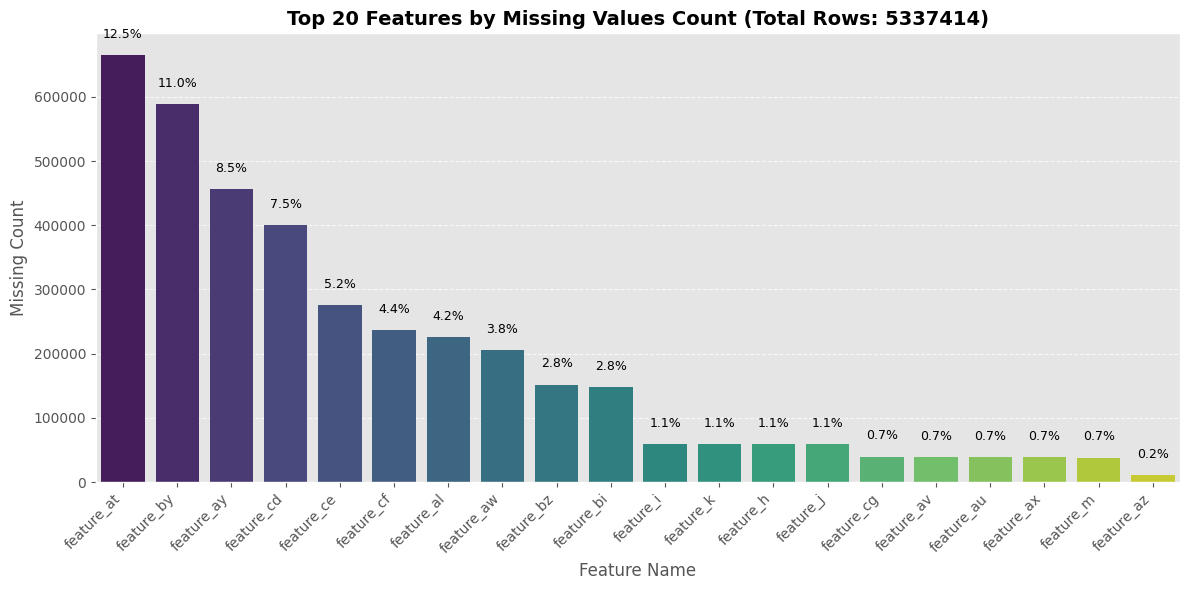


**Missing Data Summary Table (Top 10):**
|            |   Missing_Count |   Missing_Percent |
|:-----------|----------------:|------------------:|
| feature_at |       665676.00 |             12.47 |
| feature_by |       588140.00 |             11.02 |
| feature_ay |       455920.00 |              8.54 |
| feature_cd |       400114.00 |              7.50 |
| feature_ce |       275829.00 |              5.17 |
| feature_cf |       236389.00 |              4.43 |
| feature_al |       225416.00 |              4.22 |
| feature_aw |       205194.00 |              3.84 |
| feature_bz |       151722.00 |              2.84 |
| feature_bi |       147432.00 |              2.76 |


In [10]:
missing_summary = missing_duplicates_analysis(train_df)

Missingness in features with missing values is strongly time-structured and not random.

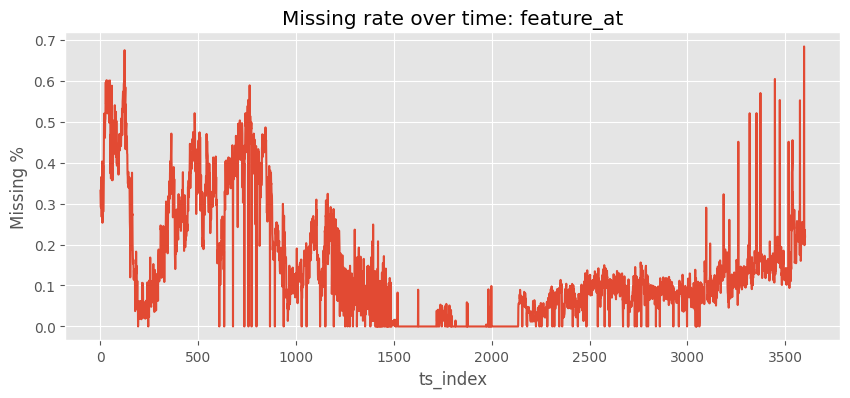

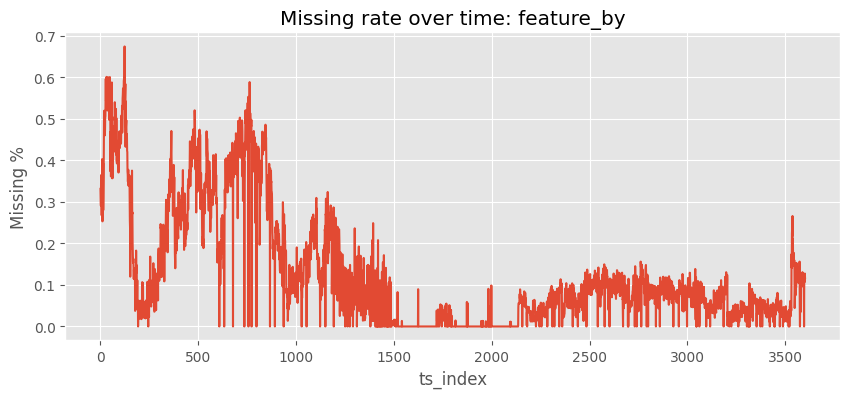

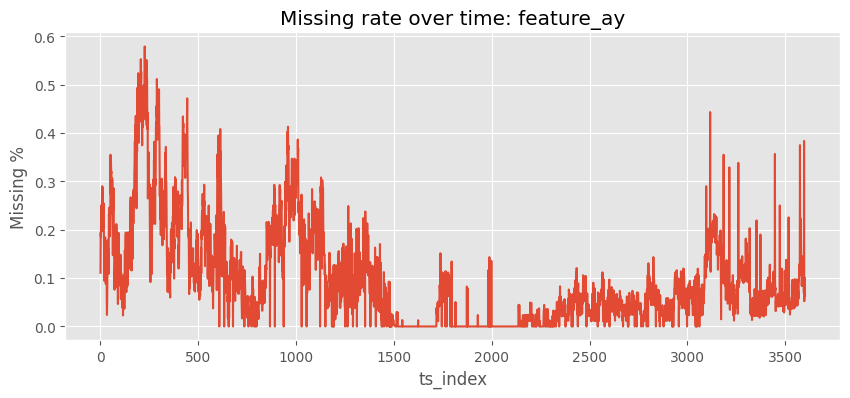

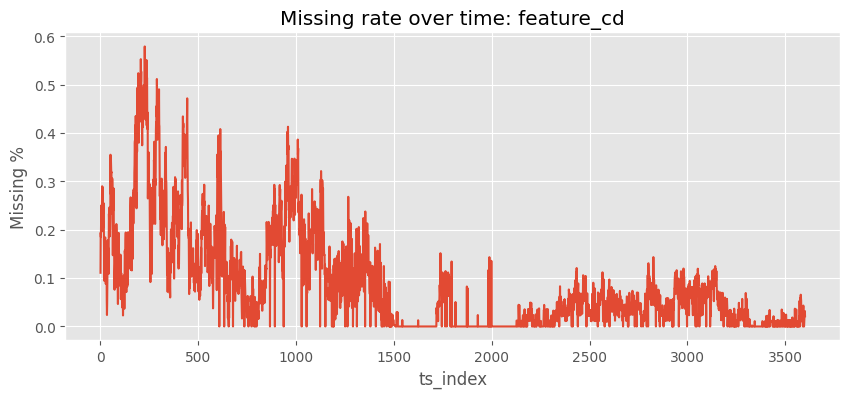

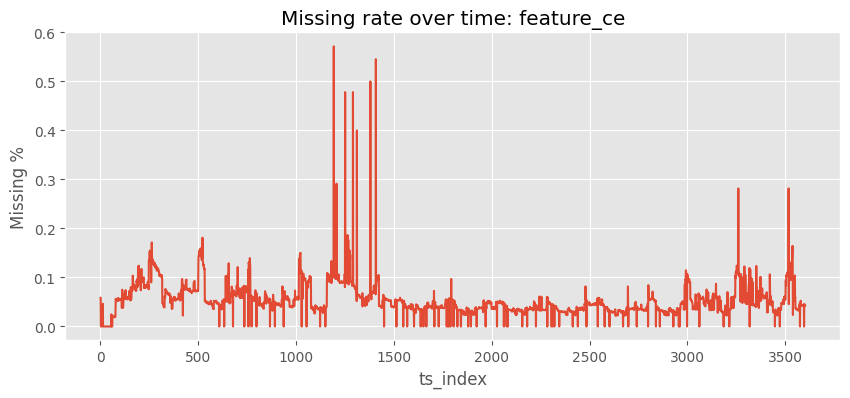

In [11]:
for feat in list(missing_summary.index)[:5]:
    plot_missing_over_time(train_df, feat)

It seems that there is some data quality drift indicator.

There are three periods of quality and missingness.
- Early (0 - 1500)
Most volatile period with the highest missing rate.

- Middle (~1500 – 3000)
Missing rate drops significantly, in general is stable with a spike in ~2300-2400.


- Late (~3000+)
Missing rate increases again and some features become unavaileble with periodic spikes.

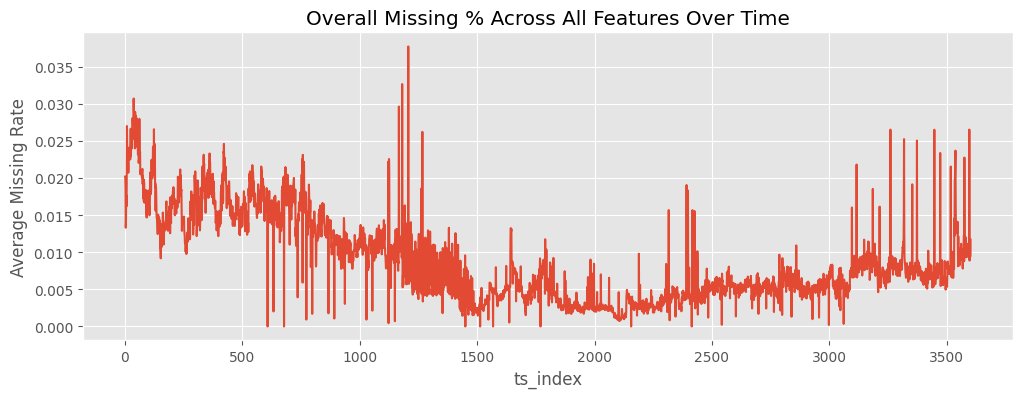

In [12]:
plot_overall_missing_drift(train_df)

IQR (Inter Quartile Range) flags 20–35% of data as outliers across many features. This means that the distribution is heavy-tailed or non-stationary since IQR assumes stable symmetric distribution.

Features like feature_al, feature_n, feature_x possibly have skewed distributions and abnormal shifts.

y_target has 28% outliers and this is very important. Target is possibly time dependent/heteroskedastic. The reason for this could be similar to the mechanism which governs the missing values in the plots above.

weight has 20% outliers. Again distribition is highly skewed and weighted RMSE may be dominated by extreme rows.

In [13]:
outliers, summary = detect_outliers(train_df, method='iqr')

📊 Outlier Detection Summary:
            outlier_count  percent_outliers
feature_al        1867767             34.99
feature_n         1580906             29.62
y_target          1541019             28.87
feature_x         1168621             21.89
feature_ag        1138052             21.32
weight            1106144             20.72
feature_z         1098507             20.58
feature_bo        1086076             20.35
feature_ao        1039655             19.48
feature_y         1028747             19.27
feature_bl         952185             17.84
feature_cc         918727             17.21
feature_ba         881746             16.52
feature_bc         864795             16.20
feature_u          853098             15.98
feature_az         840392             15.75
feature_cd         810212             15.18
feature_bg         806590             15.11
feature_r          792924             14.86
feature_o          739646             13.86
feature_bm         733305             13.74
fea

Features with high % of outliers have:
- high peak near 0.
- Long symmetric heavy tails.
- Extreme values.
- Non linear relationship with target.

Features with low % of outliers:
- Almost uniform like distribution.
- Bounded range.
- No extreme spikes.
- Weak signal with target.

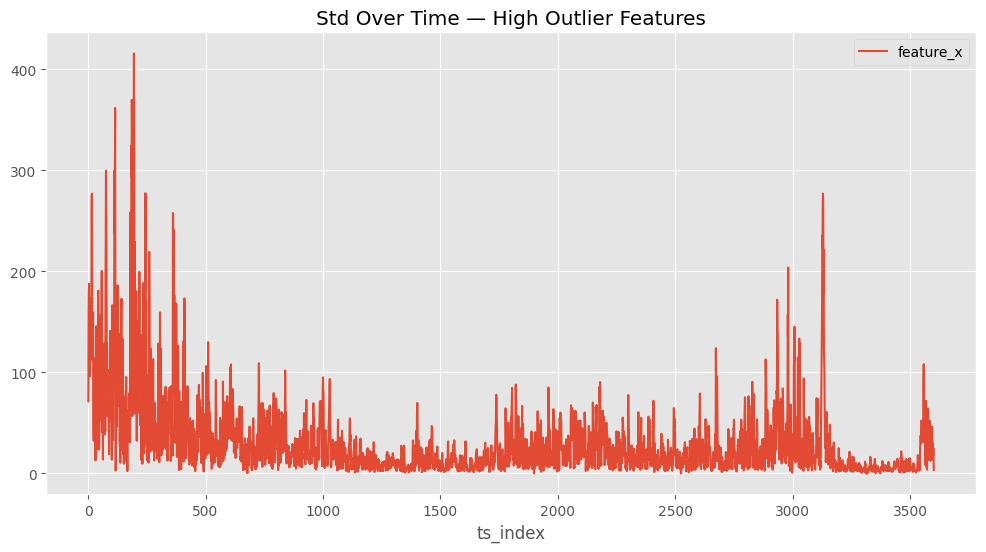

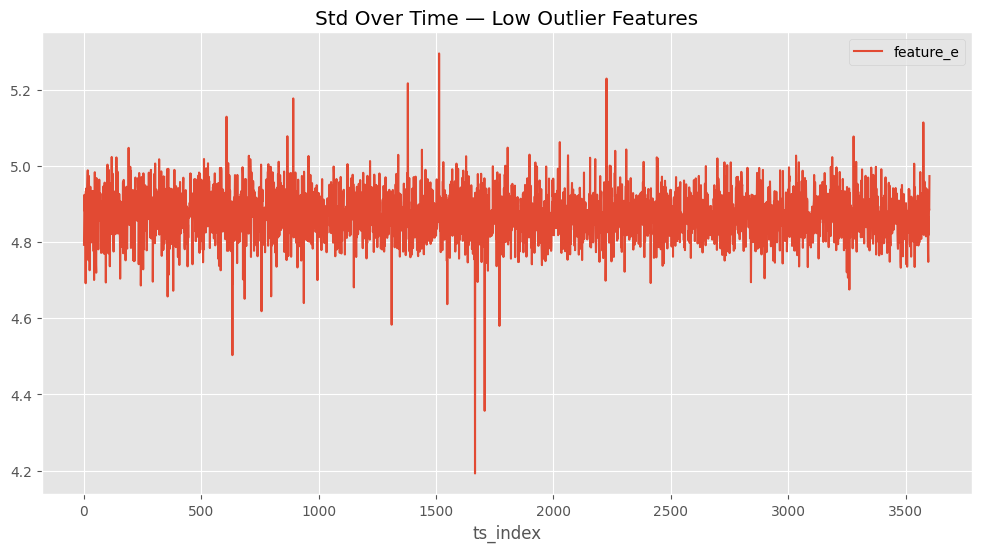

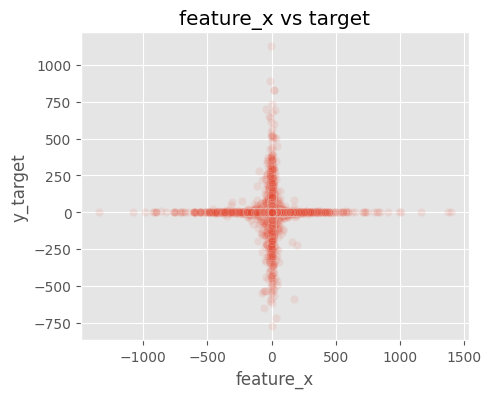

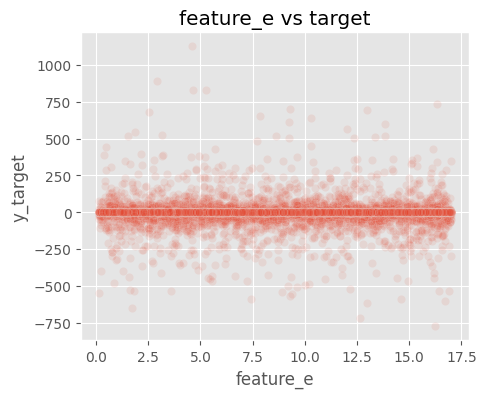

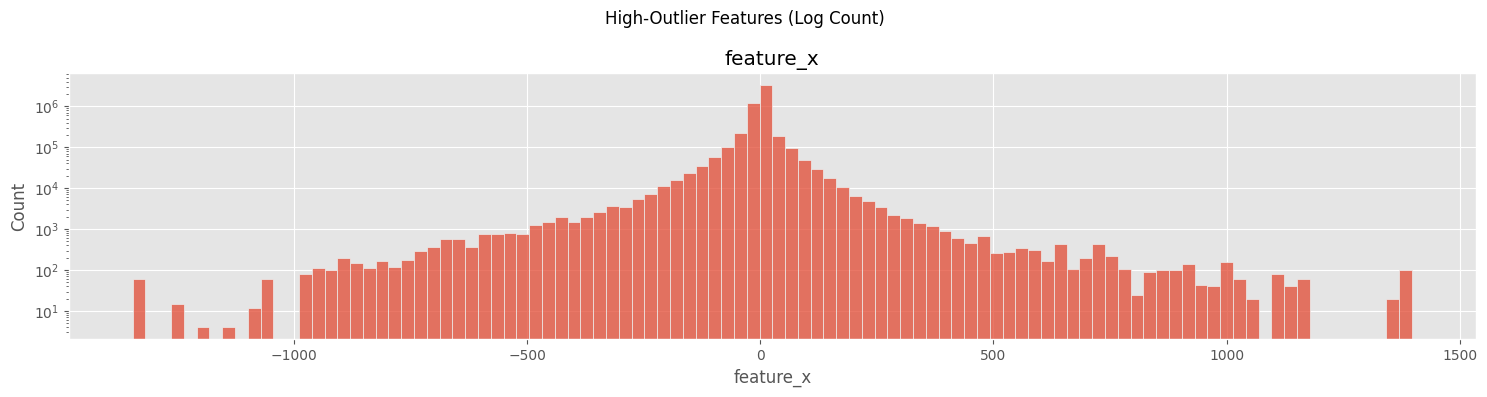

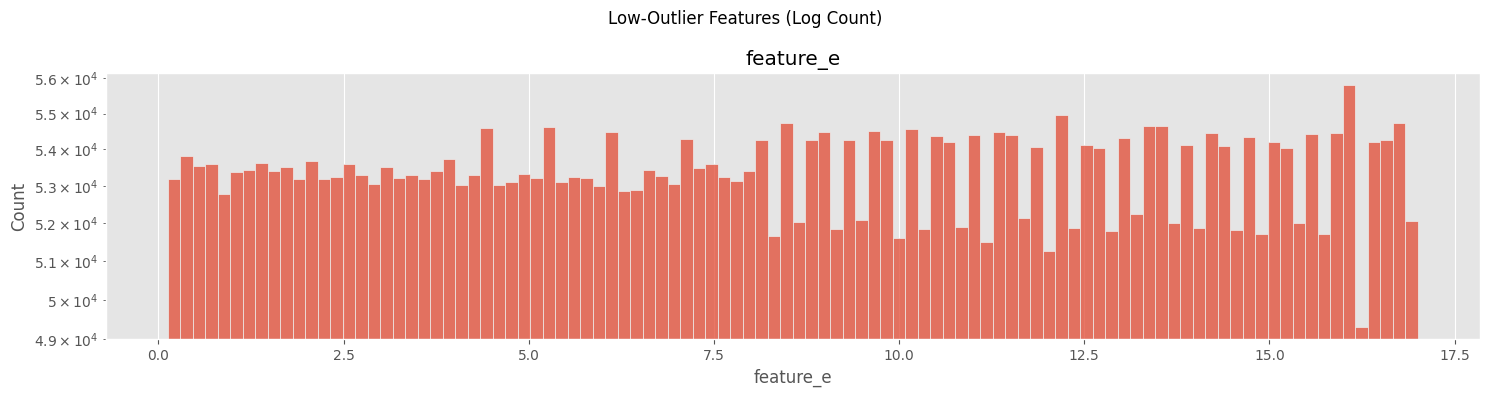

In [14]:
high_outlier_features = ["feature_x"]
low_outlier_features = ["feature_e"]

plot_std_over_time(train_df, high_outlier_features,
                   "Std Over Time — High Outlier Features")

plot_std_over_time(train_df, low_outlier_features,
                   "Std Over Time — Low Outlier Features")

plot_vs_target(train_df, high_outlier_features)
plot_vs_target(train_df, low_outlier_features)

compare_distributions(train_df, high_outlier_features, 
                      "High-Outlier Features (Log Count)")
compare_distributions(train_df, low_outlier_features, 
                      "Low-Outlier Features (Log Count)")

Target variance is also time-dependent.

<Axes: xlabel='ts_index'>

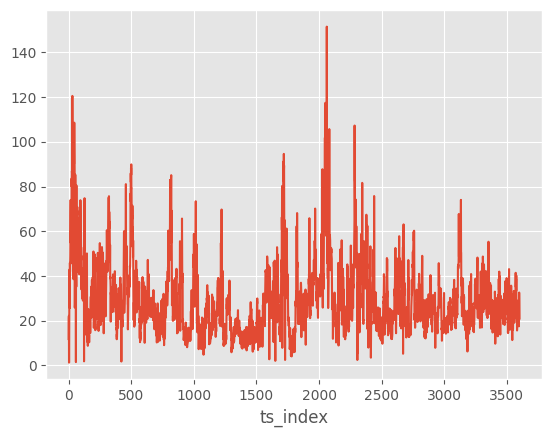

In [15]:
train_df.groupby("ts_index")[TARGET_COLUMN].std().plot()


This finding is interesting. It seems one period has extreme weights so potentially a small number of rows will dominate the gradient and model will focus mainly on them.

Is this happening only in training or is this something that will happen also in test? 

<Axes: xlabel='ts_index'>

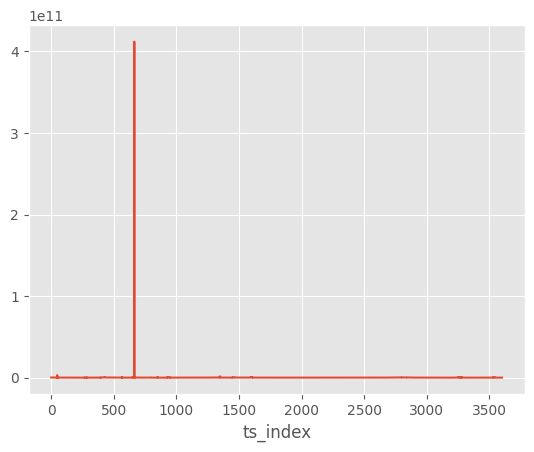

In [16]:
train_df.groupby("ts_index")["weight"].std().plot()

In [17]:
w = train_df[WEIGHT_COLUMN]

total_weight = w.sum()

top_ts = (
    train_df.groupby("ts_index")[WEIGHT_COLUMN]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

weight_top_ts = (
    train_df.loc[train_df["ts_index"] == top_ts, WEIGHT_COLUMN]
    .sum()
)

print("Top ts_index:", top_ts)
print("Share of total weight:", weight_top_ts / total_weight)

Top ts_index: 665
Share of total weight: 0.16519392


There is a strong inverse relationship between target magnitude and weight.

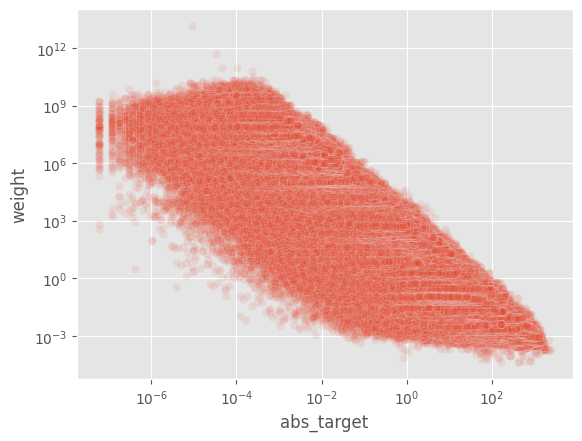

In [18]:
train_df["abs_target"] = train_df[TARGET_COLUMN].abs()

sns.scatterplot(
    x=train_df["abs_target"],
    y=train_df["weight"],
    alpha=0.1
)
plt.xscale("log")
plt.yscale("log")
plt.show()

In [19]:
tmp = train_df[
    (train_df["abs_target"] > 0) &
    (train_df["weight"] > 0)
]

log_y = np.log(tmp["abs_target"])
log_w = np.log(tmp["weight"])

mask = np.isfinite(log_y) & np.isfinite(log_w)

log_y = log_y[mask]
log_w = log_w[mask]

corr = np.corrcoef(log_y, log_w)[0,1]

print("Log-log correlation:", corr)

slope, intercept, r_value, _, _ = stats.linregress(log_y, log_w)
print("Slope:", slope)

Log-log correlation: -0.9129607308566284
Slope: -1.6724979034589396


We want to understand which features have
(a) stable predictive signal
(b) under which regimes (time / hierarchy / horizon)
(c) without leaking future information.

In [20]:
# Count unique values
cat_cardinality = (
    train_df[CATEGORICAL_COLUMNS]
    .nunique()
    .sort_values(ascending=False)
)

cat_cardinality

sub_code        180
code             23
sub_category      5
horizon           4
dtype: int64

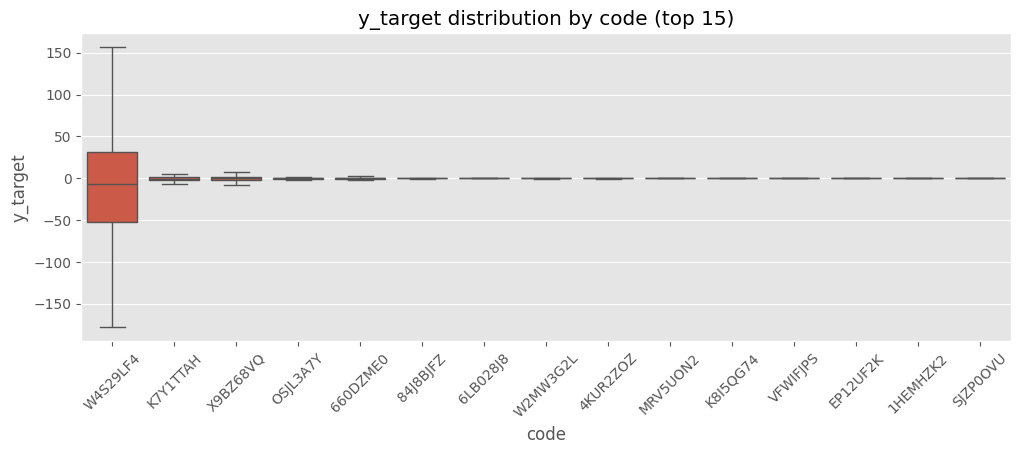

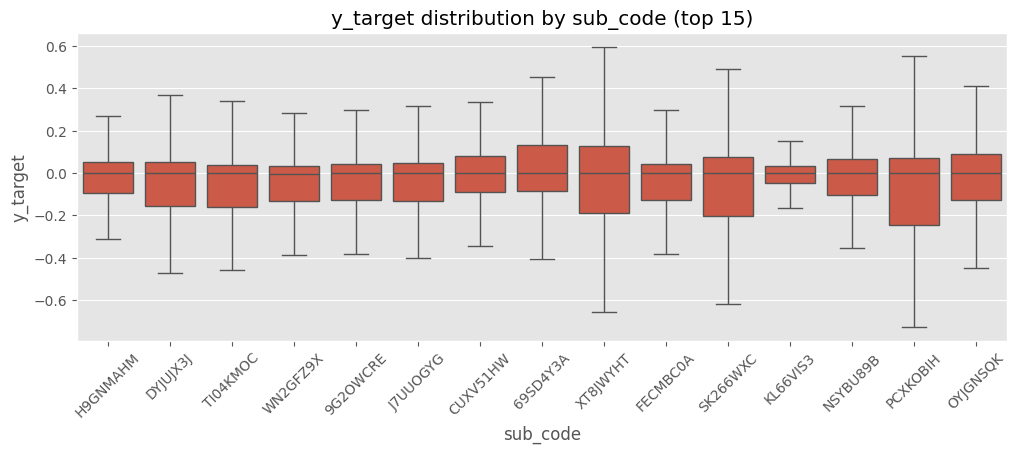

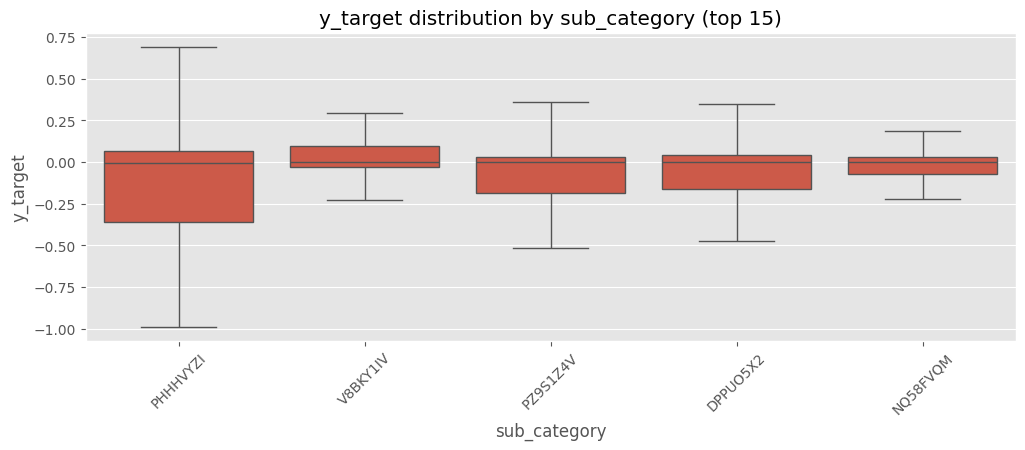

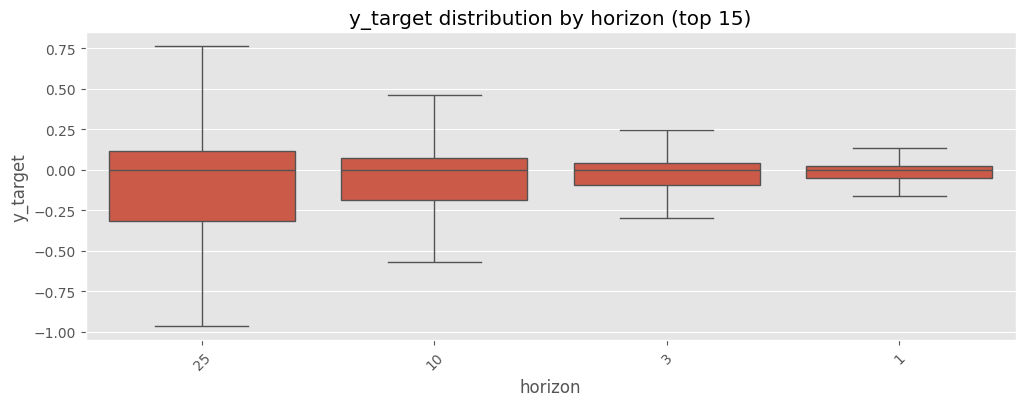

In [21]:
for cat in CATEGORICAL_COLUMNS:
    plot_target_boxplot_by_range(
        df=train_df,
        category_col=cat,
        top_k=15,
        range_method="minmax"
    )

Target sanity checks

In [22]:
sns.set_style("whitegrid")

RANDOM_STATE = 2
SAMPLE_SIZE = 100000 

analysis_df = (
    train_df
    .sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
    .sort_values("ts_index")
    .reset_index(drop=True)
)

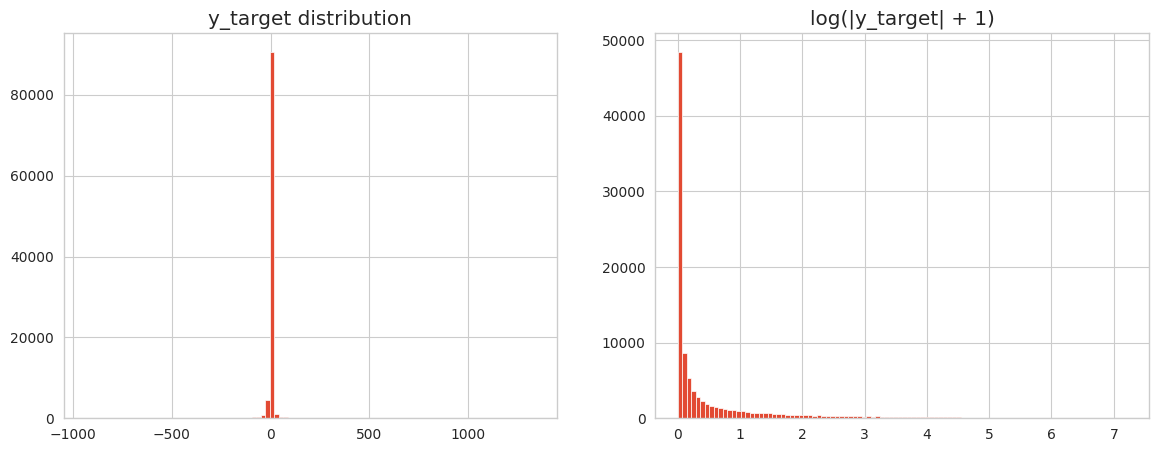

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(analysis_df["y_target"], bins=100)
axes[0].set_title("y_target distribution")

axes[1].hist(np.log1p(np.abs(analysis_df["y_target"])), bins=100)
axes[1].set_title("log(|y_target| + 1)")

plt.show()

In [24]:
base_features = [c for c in analysis_df.columns if c.startswith("feature_")][:30]
corr_df = corr_summary(analysis_df, base_features)
corr_df.head(10)

,feature,spearman,pearson
20,feature_u,-0.092479,-0.081848
21,feature_v,-0.077421,-0.026199
16,feature_q,-0.076618,-0.007298
19,feature_t,-0.075365,-0.039734
15,feature_p,-0.075051,-0.021317
18,feature_s,-0.072583,-0.068359
17,feature_r,-0.068786,-0.001815
29,feature_ad,0.044139,0.008316
14,feature_o,-0.039183,-0.064514
8,feature_i,0.036952,0.002306


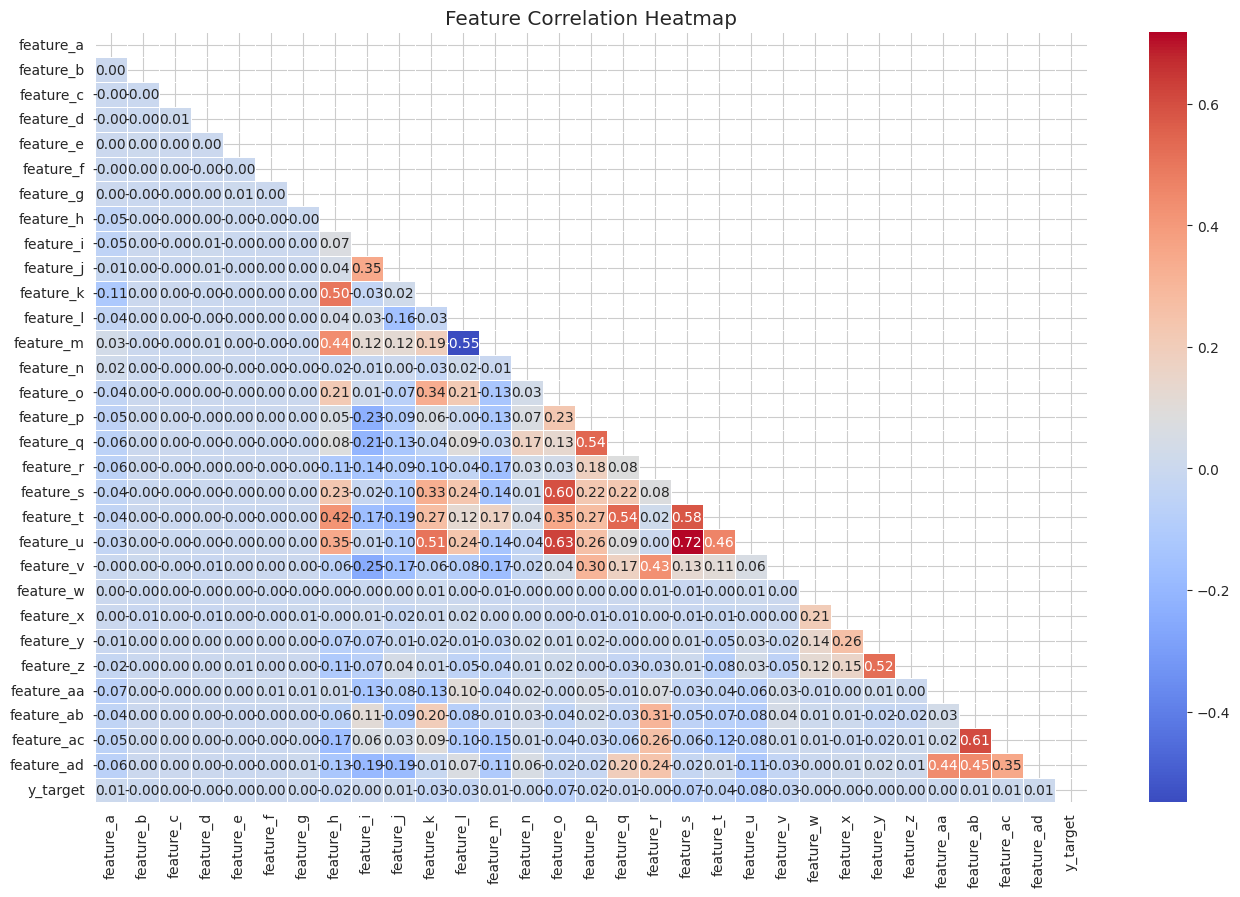

In [25]:
plot_correlation_matrix(analysis_df, base_features + [TARGET_COLUMN])

feature_al vs y_target
  Pearson  r = -0.0017
  Spearman ρ = 0.0535


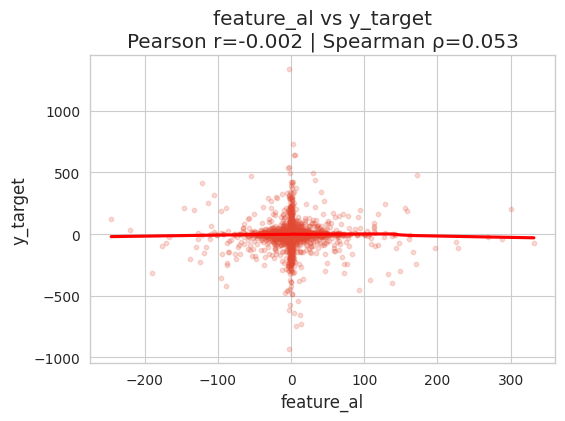

In [26]:
plot_scatter_feature_vs_target(analysis_df, 'feature_al', 'y_target')

feature_u vs y_target
  Pearson  r = -0.0495
  Spearman ρ = -0.0985


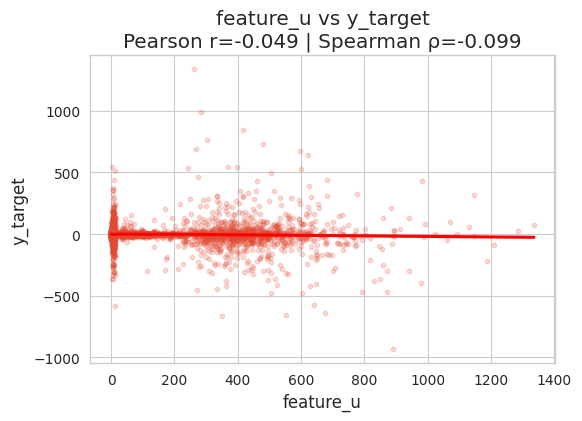

feature_v vs y_target
  Pearson  r = -0.0213
  Spearman ρ = -0.0865


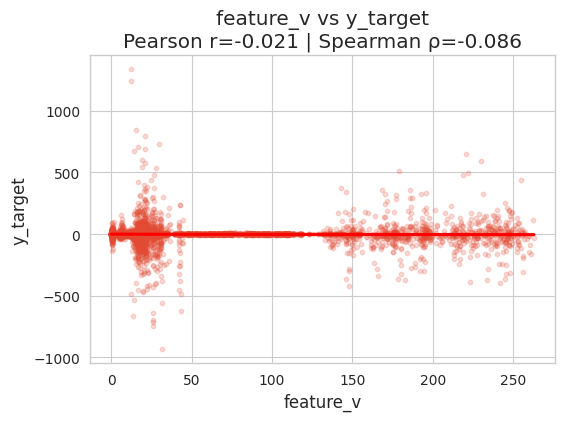

feature_q vs y_target
  Pearson  r = -0.0024
  Spearman ρ = -0.0787


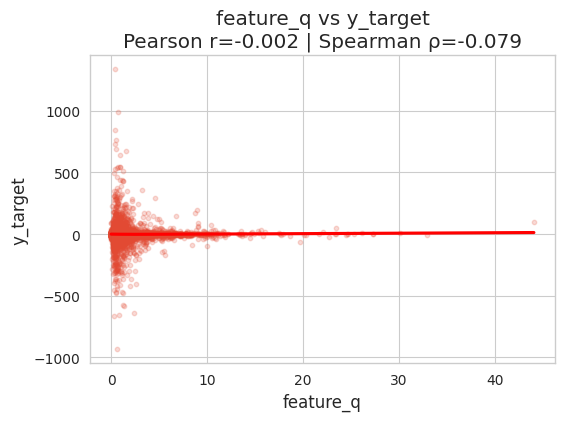

feature_t vs y_target
  Pearson  r = -0.0511
  Spearman ρ = -0.0753


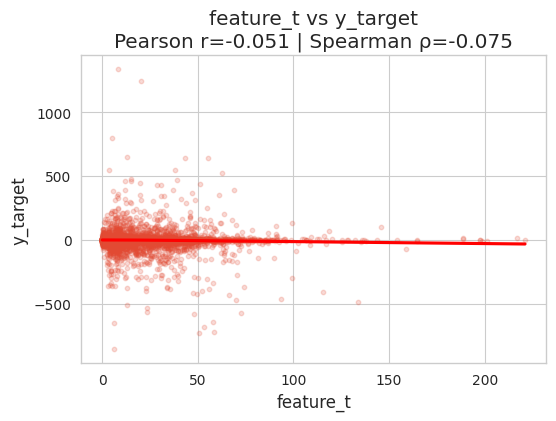

feature_p vs y_target
  Pearson  r = -0.0325
  Spearman ρ = -0.0824


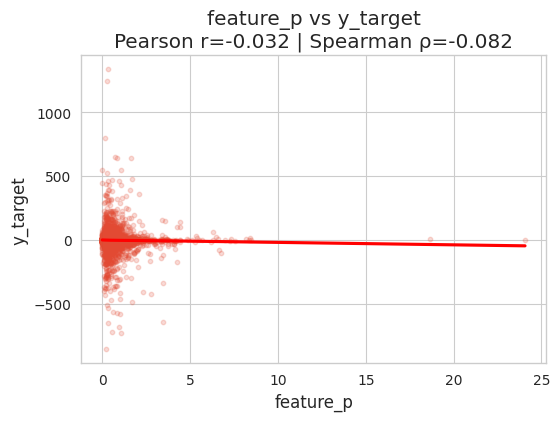

feature_s vs y_target
  Pearson  r = -0.1203
  Spearman ρ = -0.0705


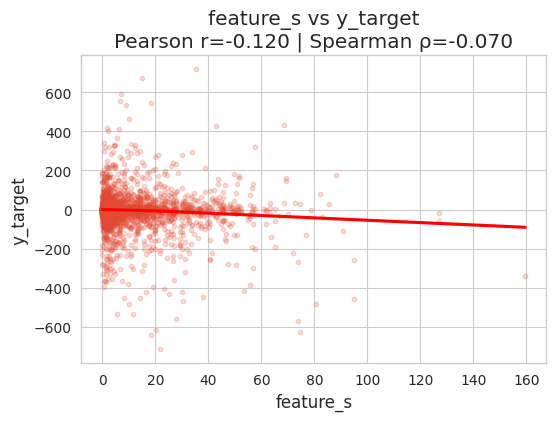

feature_r vs y_target
  Pearson  r = -0.0029
  Spearman ρ = -0.0693


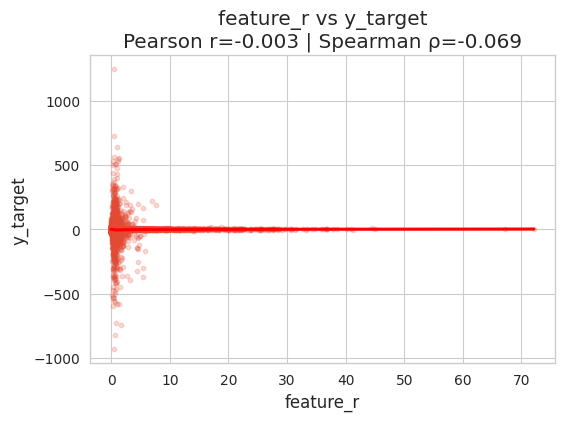

feature_ad vs y_target
  Pearson  r = 0.0122
  Spearman ρ = 0.0448


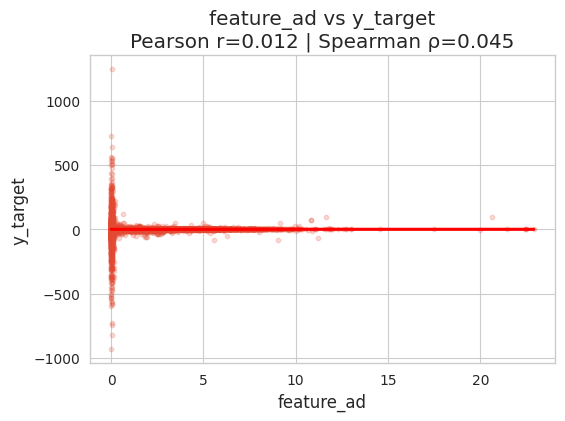

feature_o vs y_target
  Pearson  r = -0.0830
  Spearman ρ = -0.0372


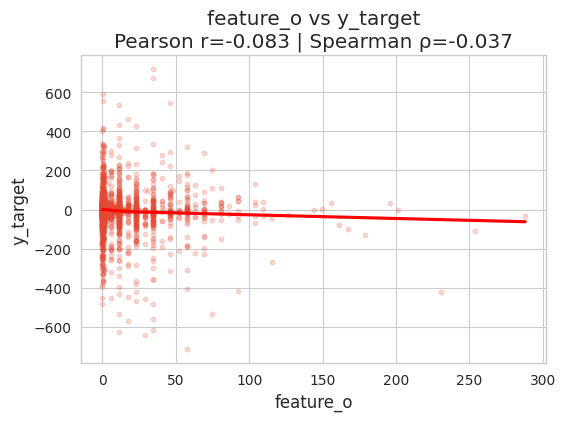

feature_i vs y_target
  Pearson  r = 0.0025
  Spearman ρ = 0.0396


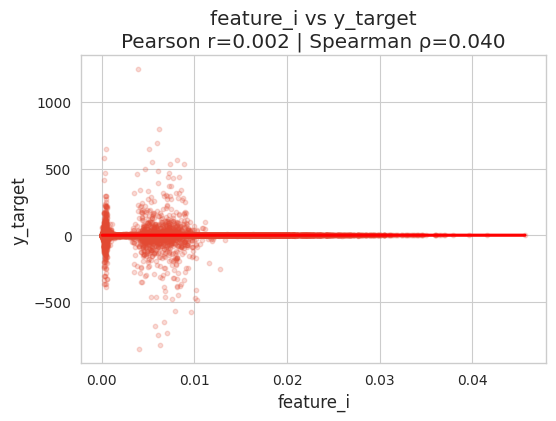

In [27]:
for feat in list(corr_df['feature'].head(10)):
    plot_scatter_feature_vs_target(analysis_df, feat)


## Training Pipeline

In [28]:
main_feature_cols = [c for c in train_df.columns if c.startswith('feature_')]

train_df = build_features(train_df, main_feature_cols)

NUMERIC_FEATURES = [c for c in train_df.columns if c.startswith('feature_')]

MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_COLUMNS
print(len(MODEL_FEATURES))
for c in CATEGORICAL_COLUMNS:
    train_df[c] = train_df[c].astype("category")
    test_df[c]  = test_df[c].astype("category")

936


## Feature Selection

In [29]:
lgb_fs_params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.04,
    "num_leaves": 255,
    "min_data_in_leaf": 300,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "lambda_l1": 0.0,
    "lambda_l2": 5.0,
    "max_depth": 8,
    "verbosity": -1,
    "seed": 13,
}

df_fs = train_df.sample(150000).copy()
df_fs = df_fs.sort_values("ts_index")
# compute clipping thresholds
low = df_fs[WEIGHT_COLUMN].quantile(0.1)
high = df_fs[WEIGHT_COLUMN].quantile(0.9)

df_fs[WEIGHT_COLUMN] = df_fs[WEIGHT_COLUMN].clip(low, high)

result = select_top_features_lgb_gain(
    df=df_fs,
    model_features=MODEL_FEATURES,
    categorical_columns=CATEGORICAL_COLUMNS,
    target_col=TARGET_COLUMN,
    weight_col=WEIGHT_COLUMN,
    lgb_params=lgb_fs_params,
    top_k=73,
    n_folds=5,
    min_train_fraction=0.7,
    valid_fraction=0.10,
    time_col="ts_index",
    num_boost_round=150,
    early_stopping_rounds=25,
)

SELECTED_FEATURES = result["top_features"]
#make sure categoricals are also present in the selected features
SELECTED_FEATURES = list(set(SELECTED_FEATURES) | set(CATEGORICAL_COLUMNS))


print("Top k features:")
print(SELECTED_FEATURES)

gc.collect()

[Fold 1] best_iter=1 valid_skill=0.00000000
[Fold 2] best_iter=5 valid_skill=0.02484450
[Fold 3] best_iter=19 valid_skill=0.02654586
[Fold 4] best_iter=13 valid_skill=0.04694710
[Fold 5] best_iter=11 valid_skill=0.06677306
Top k features:
['feature_m_vs_sub_category', 'feature_ag_vs_sub_category', 'feature_bg_sub_code_mean', 'feature_m_vs_sub_code', 'feature_bp_lag1', 'feature_g_x_feature_i', 'feature_a_horizon_mean', 'feature_bq', 'feature_az_horizon_mean', 'feature_ai_vs_sub_category', 'feature_by_vs_sub_category', 'feature_by_lag1', 'feature_bx', 'feature_i_vs_horizon', 'feature_cc', 'feature_aq', 'feature_r_vs_sub_category', 'feature_cc_lag1', 'sub_category', 'feature_bj_lag24', 'feature_j_vs_sub_category', 'feature_m_vs_horizon', 'feature_v_vs_sub_category', 'feature_am_vs_sub_code', 'code', 'feature_cb', 'feature_h', 'feature_bz_vs_horizon', 'feature_l_lag24', 'feature_by_vs_sub_code', 'feature_am', 'feature_bg_horizon_mean', 'feature_al_lag1', 'feature_bq_lag1', 'feature_al', 'f

0

## Training Strategy 1

Horizon-specific models with time-aware validation and ensemble learning.

In [30]:
BASE_PARAMS = {
    "objective": "regression",
    "metric": "None",
    "learning_rate": 0.03,
    "num_leaves": 1027,
    "min_data_in_leaf": 100,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "lambda_l1": 1.0,
    "lambda_l2": 5.0,
    "max_depth": 16,
    "min_gain_to_split": 0.01,
    "verbosity": -1,
}

HORIZON_OVERRIDES = {
    1:  {"num_leaves": 1063,  "lambda_l2": 10.0, "min_data_in_leaf": 500},
    3:  {"num_leaves": 1027, "lambda_l2": 7.0,  "min_data_in_leaf": 200},
    10: {"num_leaves": 1027, "lambda_l2": 5.0,  "min_data_in_leaf": 100},
    25: {"num_leaves": 1255, "lambda_l2": 3.0,  "min_data_in_leaf": 80},
}

In [31]:
test_df = build_features(test_df, main_feature_cols)
test_df = test_df[["id"]+ SELECTED_FEATURES]

In [32]:
results = train_lgb_competition_pipeline(
    train_df=train_df,
    test_df=test_df,
    feature_cols=SELECTED_FEATURES,
    categorical_cols=CATEGORICAL_COLUMNS,
    target_col=TARGET_COLUMN,
    weight_col=WEIGHT_COLUMN,
    horizon_col="horizon",
    time_col="ts_index",
    id_col="id",
    horizons=(1, 3, 10, 25),
    seeds=(13, 23, 37),
    n_folds=3,
    valid_fraction=0.10,
    min_train_fraction=0.90,
    weight_method="clip",
    clip_target_quantiles=None,  
    base_params=BASE_PARAMS,
    horizon_overrides=HORIZON_OVERRIDES,
    num_boost_round=3000,
    early_stopping_rounds=150,
)

gc.collect()


HORIZON 1
Train rows: 1,394,653
Test rows : 379,617
Features  : 74
duplicate columns: []
num duplicate columns: 0

[H=1] Fold 1/2
  train cutoff: 3240 | valid range: [3241, 3600]
  train rows: 1,235,423 | valid rows: 158,745
  best_iteration mean: 1.0
  weighted RMSE: 0.001138
  weighted MAE : 0.000210
  RMSE         : 100.180817
  MAE          : 2.353211

[H=1] Fold 2/2
  train cutoff: 3241 | valid range: [3242, 3601]
  train rows: 1,235,846 | valid rows: 158,807
  best_iteration mean: 1.0
  weighted RMSE: 0.001137
  weighted MAE : 0.000209
  RMSE         : 100.185440
  MAE          : 2.353493

[H=1] OOF summary
{'horizon': 1, 'weighted_rmse': 0.0011369324576646122, 'weighted_mae': 0.00020975820566269748, 'rmse': 100.06371307373047, 'mae': 2.352670669555664, 'n_oof_rows': 159230}

HORIZON 3
Train rows: 1,385,816
Test rows : 376,558
Features  : 74
duplicate columns: []
num duplicate columns: 0

[H=3] Fold 1/2
  train cutoff: 3240 | valid range: [3241, 3600]
  train rows: 1,227,776 | v

0

In [33]:
print(results["trained_summary"])
print(results["horizon_scores"].sort_values("horizon"))
print(results["fold_scores"].sort_values(["horizon", "fold"]))

{'overall_weighted_rmse': 0.002599362395946943, 'overall_weighted_mae': 0.00044828843968034083, 'overall_rmse': 764.1605834960938, 'overall_mae': 6.276470184326172, 'n_oof_rows': 607470}
   horizon  weighted_rmse  weighted_mae         rmse        mae  n_oof_rows
0        1       0.001137      0.000210   100.063713   2.352671      159230
1        3       0.001896      0.000359   282.461761   4.098741      158040
2       10       0.002957      0.000561   885.319641   7.651456      151674
3       25       0.003893      0.000741  1944.409424  11.765731      138526
   horizon  fold  train_cutoff  valid_start  valid_end  best_iteration_mean  \
0        1     1          3240         3241       3600             1.000000   
1        1     2          3241         3242       3601             1.000000   
2        3     1          3240         3241       3600             1.000000   
3        3     2          3241         3242       3601             1.000000   
4       10     1          3240        

In [34]:
oof = results["oof_df"]
print(
    oof.groupby("horizon")["prediction"]
    .agg(["min", "max", "mean", "std"])
)

              min       max      mean           std
horizon                                            
1       -0.000009 -0.000009 -0.000009  2.725876e-09
3       -0.000024 -0.000024 -0.000024  2.026024e-09
10      -0.002001 -0.000042 -0.000944  8.037708e-04
25      -0.024412  0.007066 -0.009858  1.004657e-02


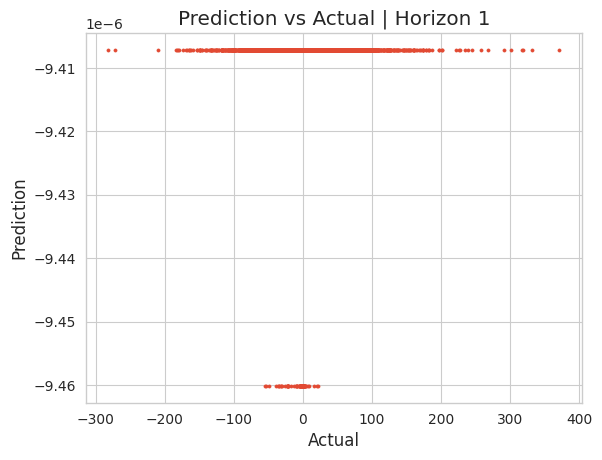

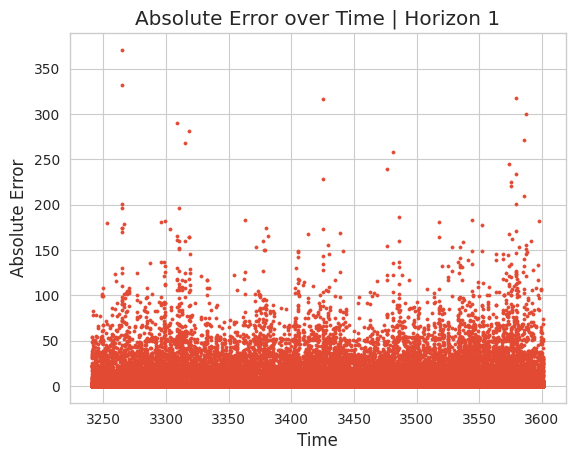

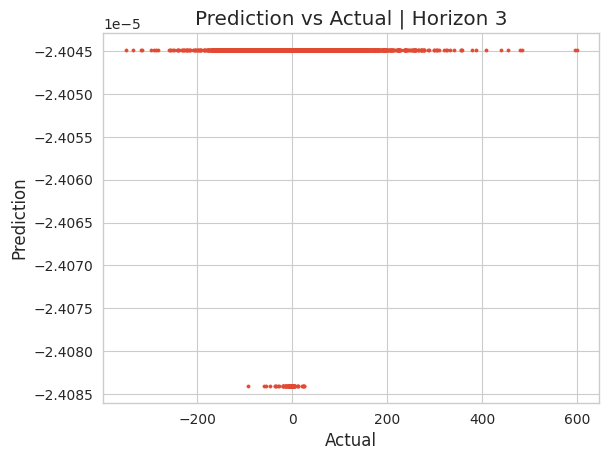

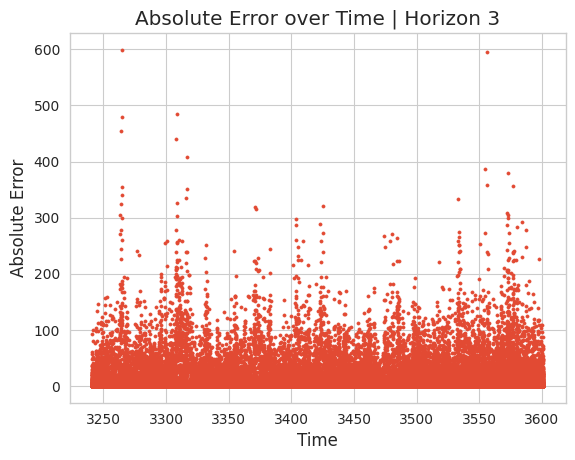

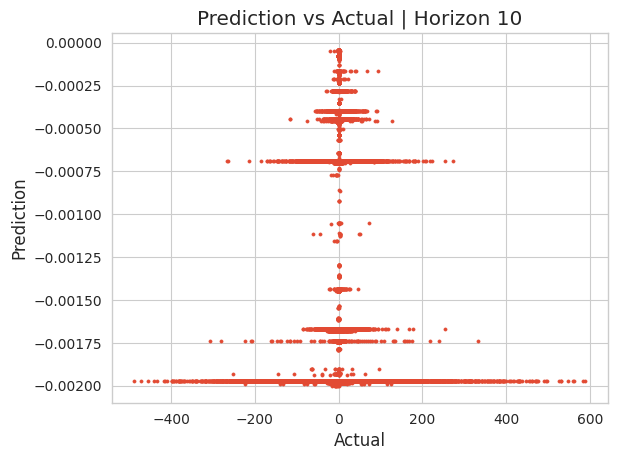

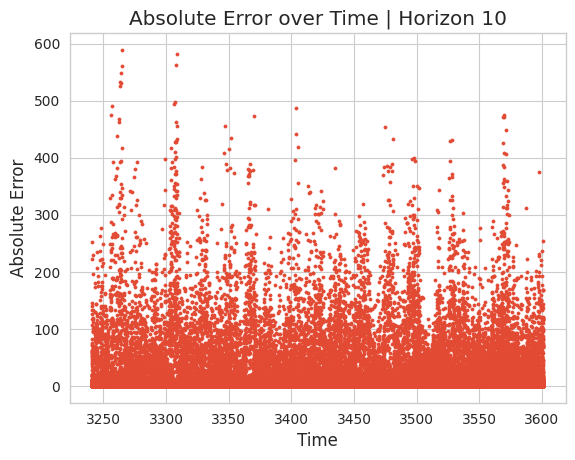

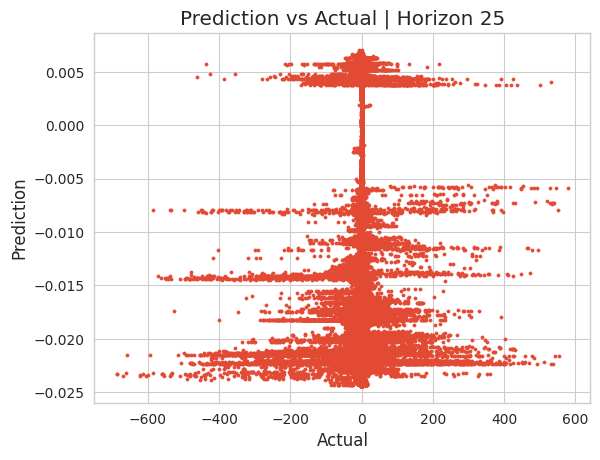

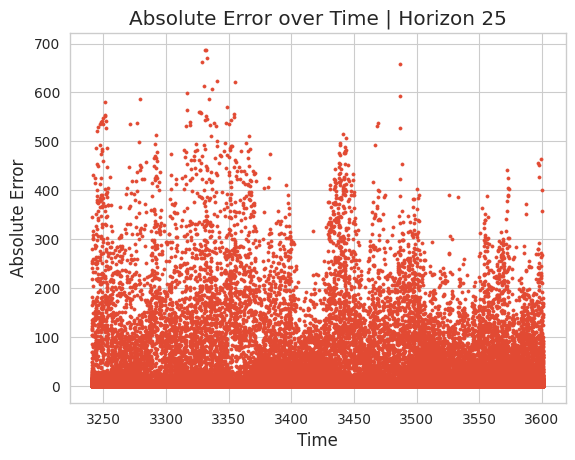

In [35]:
oof = results["oof_df"].dropna(subset=["prediction"]).copy()

for h in sorted(oof["horizon"].unique()):
    sub = oof[oof["horizon"] == h]

    plt.figure()
    plt.scatter(sub[TARGET_COLUMN], sub["prediction"], s=5)
    plt.xlabel("Actual")
    plt.ylabel("Prediction")
    plt.title(f"Prediction vs Actual | Horizon {h}")
    plt.show()

    resid = sub[TARGET_COLUMN] - sub["prediction"]
    plt.figure()
    plt.scatter(sub["ts_index"], np.abs(resid), s=5)
    plt.xlabel("Time")
    plt.ylabel("Absolute Error")
    plt.title(f"Absolute Error over Time | Horizon {h}")
    plt.show()

In [36]:
submission_strategy1 = results["submission_df"][["id", "prediction"]].copy()
submission_strategy1.to_csv("submission_strategy1.csv", index=False)
print("Saved submission_strategy1.csv")

gc.collect()

Saved submission_strategy1.csv


13635

## Training Strategy 2

Single-split, time-aware training strategy with weighted learning and recency weights.

In [37]:
# compute clipping thresholds
low = train_df[WEIGHT_COLUMN].quantile(0.05)
high = train_df[WEIGHT_COLUMN].quantile(0.95)
train_df[WEIGHT_COLUMN] = train_df[WEIGHT_COLUMN].clip(low, high)

trn_idx, val_idx, cut_ts = make_time_split(train_df, valid_fraction=0.1)
print("time cutoff ts_index:", cut_ts)
print("train rows:", len(trn_idx), "valid rows:", len(val_idx))

X_trn = train_df.loc[trn_idx, SELECTED_FEATURES]
y_trn = train_df.loc[trn_idx, TARGET_COLUMN].astype(np.float32)
w_trn = train_df.loc[trn_idx, WEIGHT_COLUMN].astype(np.float32)

X_val = train_df.loc[val_idx, SELECTED_FEATURES]
y_val = train_df.loc[val_idx, TARGET_COLUMN].astype(np.float32)
w_val = train_df.loc[val_idx, WEIGHT_COLUMN].astype(np.float32)

# LightGBM datasets
dtrain = lgb.Dataset(X_trn, label=y_trn, weight=w_trn, categorical_feature=CATEGORICAL_COLUMNS, free_raw_data=False)
dvalid = lgb.Dataset(X_val, label=y_val, weight=w_val, categorical_feature=CATEGORICAL_COLUMNS, free_raw_data=False)

gc.collect()

params = {
    "objective": "regression",
    "metric": "None",
    "learning_rate": 0.01,
    "num_leaves": 1800,
    "min_data_in_leaf": 400,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "lambda_l1": 0.0,
    "lambda_l2": 1.0,
    "max_depth": 16,
    "verbosity": -1,
    "seed": 13
}

model = lgb.train(
    params=params,
    train_set=dtrain,
    valid_sets=[dtrain, dvalid],
    valid_names=["train", "valid"],
    num_boost_round=500,
    feval=lgb_skill_metric,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=20),
    ],
)

val_pred = model.predict(X_val, num_iteration=model.best_iteration)
val_score = skill_like_score(y_val.values, val_pred, w_val.values)
print("Validation skill-like score:", val_score)

del X_trn, y_trn, w_trn, X_val, y_val, w_val, dtrain, dvalid
gc.collect()


X_full = train_df[SELECTED_FEATURES]
y_full = train_df[TARGET_COLUMN].astype(np.float32)
w_full = train_df[WEIGHT_COLUMN].astype(np.float32)

if USE_RECENCY_WEIGHTING:
    ts = train_df["ts_index"].astype(np.float32).values
    ts_min, ts_max = float(ts.min()), float(ts.max())
    rec = (ts - ts_min) / (ts_max - ts_min + 1e-6)
    recency_multiplier = 0.6 + 40 * rec
    w_full = w_full * recency_multiplier.astype(np.float32)

dfull = lgb.Dataset(
    X_full,
    label=y_full,
    weight=w_full,
    categorical_feature=CATEGORICAL_COLUMNS,
    free_raw_data=False
)

final_model = lgb.train(
    params=params,
    train_set=dfull,
    num_boost_round=int(model.best_iteration * 1.05),
)

del X_full, y_full, w_full, dfull
gc.collect()



time cutoff ts_index: 3241
train rows: 4731537 valid rows: 605877
Training until validation scores don't improve for 50 rounds
[20]	train's skill_score: 0.232761	valid's skill_score: 0.12109
[40]	train's skill_score: 0.313491	valid's skill_score: 0.153056
[60]	train's skill_score: 0.370206	valid's skill_score: 0.175879
[80]	train's skill_score: 0.412547	valid's skill_score: 0.1907
[100]	train's skill_score: 0.446441	valid's skill_score: 0.198477
[120]	train's skill_score: 0.474619	valid's skill_score: 0.205003
[140]	train's skill_score: 0.496837	valid's skill_score: 0.208922
[160]	train's skill_score: 0.514074	valid's skill_score: 0.212623
[180]	train's skill_score: 0.530087	valid's skill_score: 0.216003
[200]	train's skill_score: 0.543207	valid's skill_score: 0.218849
[220]	train's skill_score: 0.554541	valid's skill_score: 0.220585
[240]	train's skill_score: 0.564144	valid's skill_score: 0.221653
[260]	train's skill_score: 0.573132	valid's skill_score: 0.221909
[280]	train's skill_sc

46

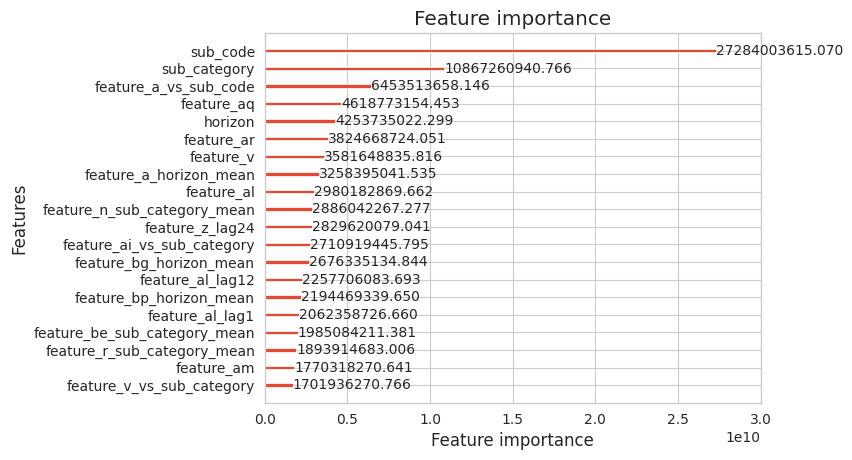

In [38]:
lgb.plot_importance(final_model, max_num_features=20, importance_type="gain")
plt.show()


In [39]:
# test_df = build_features(test_df, main_feature_cols)
X_test = test_df[SELECTED_FEATURES]
test_pred = final_model.predict(X_test)

# Build submission
submission_strategy2 = pd.DataFrame({
    "id": test_df["id"].values,
    "prediction": test_pred.astype(np.float64),
})


submission_strategy2.to_csv("submission_strategy2.csv", index=False)
print("Saved: submission_strategy2.csv")

submission_strategy2.head()

Saved: submission_strategy2.csv


,id,prediction
0,10BAVIDU__07YQ9WA4__DPPUO5X2__1__4175,-0.177653
1,10BAVIDU__07YQ9WA4__DPPUO5X2__1__4176,0.042862
2,10BAVIDU__07YQ9WA4__DPPUO5X2__1__4177,-0.005602
3,10BAVIDU__07YQ9WA4__DPPUO5X2__1__4178,0.126060
4,10BAVIDU__07YQ9WA4__DPPUO5X2__1__4179,-0.030811


## Diagnostics

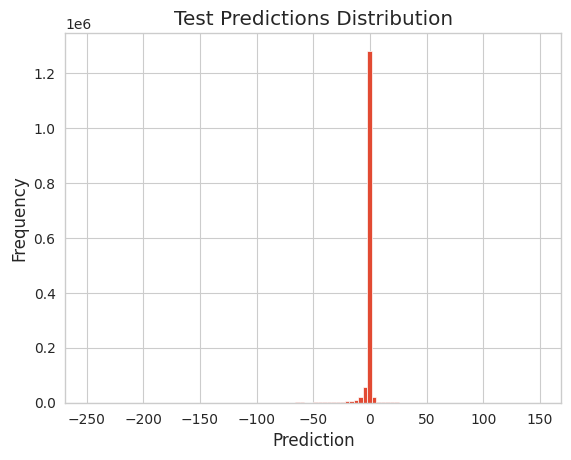

In [40]:
plt.figure()
plt.hist(test_pred, bins=100)
plt.title("Test Predictions Distribution")
plt.xlabel("Prediction")
plt.ylabel("Frequency")
plt.show()

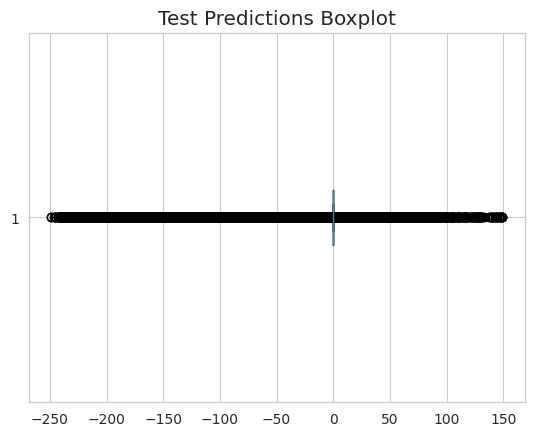

In [41]:
plt.figure()
plt.boxplot(test_pred, vert=False)
plt.title("Test Predictions Boxplot")
plt.show()

In [42]:
train_samp = train_df.sample(100000)
y_train = train_samp[TARGET_COLUMN].values
train_pred = final_model.predict(train_samp[SELECTED_FEATURES])

residuals = y_train - train_pred
abs_residuals = np.abs(residuals)

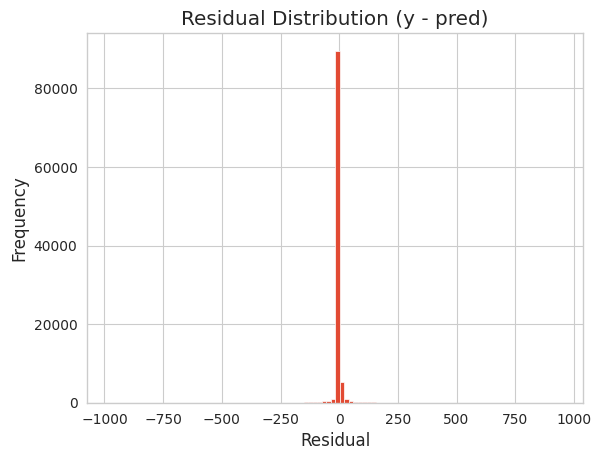

In [43]:
plt.figure()
plt.hist(residuals, bins=100)
plt.title("Residual Distribution (y - pred)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

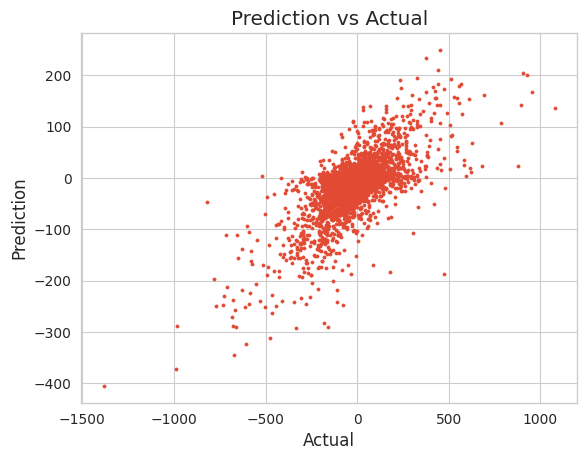

In [44]:
plt.figure()
plt.scatter(y_train, train_pred, s=5)
plt.xlabel("Actual")
plt.ylabel("Prediction")
plt.title("Prediction vs Actual")
plt.show()

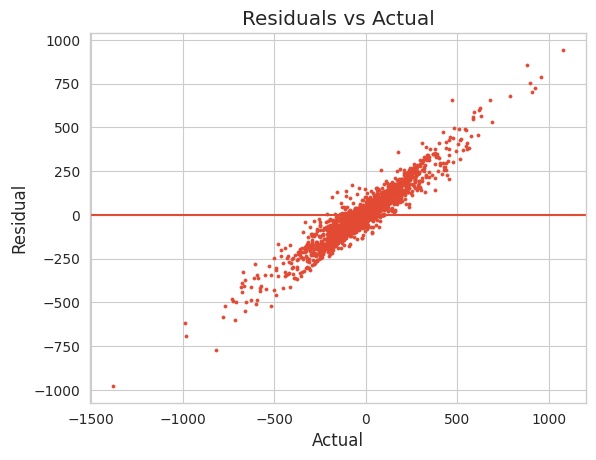

In [45]:
plt.figure()
plt.scatter(y_train, residuals, s=5)
plt.axhline(0)
plt.xlabel("Actual")
plt.ylabel("Residual")
plt.title("Residuals vs Actual")
plt.show()

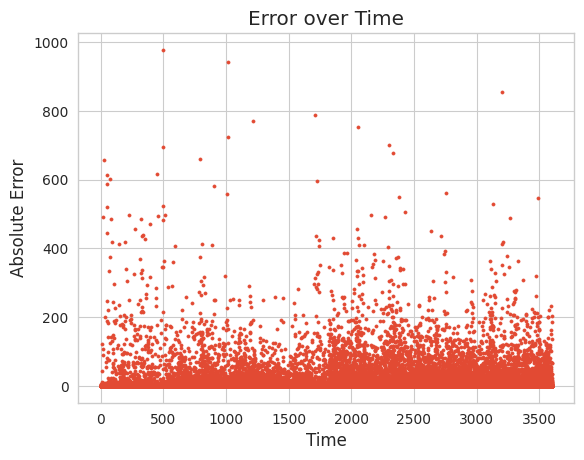

In [46]:
plt.figure()
plt.scatter(train_samp["ts_index"], abs_residuals, s=5)
plt.xlabel("Time")
plt.ylabel("Absolute Error")
plt.title("Error over Time")
plt.show()

In [47]:
print("y_train range:", y_train.min(), y_train.max())
print("train_pred range:", train_pred.min(), train_pred.max())

y_train range: -1383.0 1079.0
train_pred range: -405.31593495336557 249.17842855452338


In [48]:
tmp = train_samp[[TARGET_COLUMN, WEIGHT_COLUMN]].copy()
tmp["abs_target"] = tmp[TARGET_COLUMN].abs()

print(tmp[[WEIGHT_COLUMN, TARGET_COLUMN, "abs_target"]].corr())

              weight  y_target  abs_target
weight      1.000000  0.006878   -0.060115
y_target    0.006878  1.000000   -0.104274
abs_target -0.060115 -0.104274    1.000000


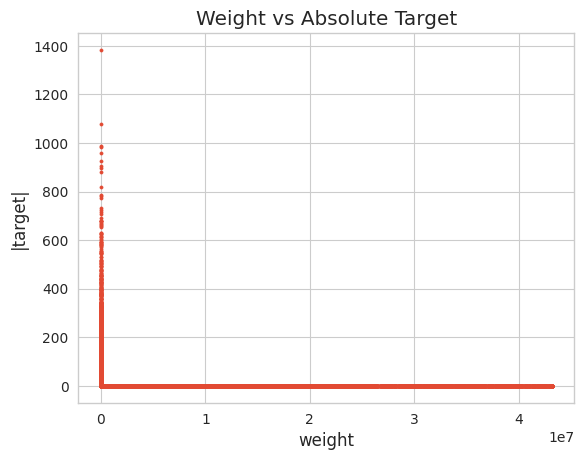

In [49]:
plt.figure()
plt.scatter(train_samp[WEIGHT_COLUMN], train_samp[TARGET_COLUMN].abs(), s=5)
plt.xlabel("weight")
plt.ylabel("|target|")
plt.title("Weight vs Absolute Target")
plt.show()